In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

# First order statistics on connectivity matrix (whole)

# Formatting

In [16]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    # "figure.figsize": (16, 6),       # Figsize
    # "figure.figsize": (8, 6),       # Figsize
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [3]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [3]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# File path handling

In [8]:
import os

figure_folder = 'figures'


In [4]:
import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Create a simple DataFrame
# -----------------------------
data = {
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [88.5, 92.0, 79.5],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Define OneDrive path
# -----------------------------
# Example (Windows):
# Path(r"C:\Users\YourUsername\OneDrive\test_folder")
#
# Example (Mac):
# Path("/Users/YourUsername/OneDrive/test_folder")

# Onedrive base where evertything will be saved
ONEDRIVE_BASE = Path(r"C:\Users\Silje\OneDrive\Dokumenter\mscneuroscience20242026\nevr3901\simulations_folder")

# Optional: ensure the folder exists
ONEDRIVE_BASE.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Save DataFrame to CSV
# -----------------------------
# csv_path = ONEDRIVE_BASE / "new_test_dataframe.csv"
# df.to_csv(csv_path, index=False)

# print(f"CSV file successfully saved to:\n{csv_path}")




# Store values for plotting

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)] 


########## Dataframe and dictionary ##########

rows = []  # Container for rows of dataframe
weights_dict = {}  # Dictionary for weight arrays

for dyn in dynamics:

    # Simulation number corresponding to dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_number:
            for seed in seed_number:
                # Loop through simulations of pqif across seeds


                dataframe_title = f'{dyn}\simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}' # load dataframe

                # dataframe_title = ONEDRIVE_BASE / f'simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}' # load dataframe

                simulation_id = f'{dyn}_{sim}_{pqif}_{seed}'  # Shared across dataframe and dictionary

                try:  # Notify if something did not exist
                    # weights_df = pd.read_csv(dataframe_title, header=None).values


                    # TODO: It is different values for these two
                    # weights_df = pd.read_csv(dataframe_title, header=None).values
                    weights_df = pd.read_csv(dataframe_title, header=None)  # Make dataframe, no header
                    weights_np = weights_df.to_numpy()  # Make numpy representation of dataframe (this is now recommended over the .values property)

                except FileNotFoundError:
                    print(f"File not found: {dataframe_title}, will be skipped.")
                    continue  # Go to next iteration


                # Flatten to 1D array
                # weights = weights_df.flatten()
                weights = weights_np.flatten()

                # Standard deviation and mean of weights for current seed of vrest/slope and pqif
                sd = np.std(weights)
                mean = np.mean(weights)

                if pqif == 1:
                    vr = None
                    f = slope_qif


                row = [simulation_id, dyn, sim, vr, f, pqif, seed, sd, mean]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
                rows.append(row)  # Append row to what becomes the dataframe later

                # weights_dict[simulation_id] = weights  # Dictionary mapping simulationID to weight array FLATTENED VERSION
                weights_dict[simulation_id] = weights_df  # Dictionary mapping simulationID to weight array


########## Make dataframe ##########

columns = ['simulationID', 'dynamic', 'simulation', 'vrest', 'slope', 'pqif', 'seed', 'std', 'mean']
df = pd.DataFrame(rows, columns=columns)


########## Make a copy of dataframe for further use ##########

wDF = df.copy()

########## Print statements to control ##########
print(wDF.head())
print(wDF.tail())
# print(weights_dict)
# for i in weights_dict.items():
#     print(i)

wDF.to_csv("stats_connectivitymatrix.csv", index=False)

         simulationID       dynamic  simulation  vrest  slope  pqif  seed  \
0  oscillations_1_0_0  oscillations           1   -8.5  14.44   0.0     0   
1  oscillations_1_0_1  oscillations           1   -8.5  14.44   0.0     1   
2  oscillations_1_0_2  oscillations           1   -8.5  14.44   0.0     2   
3  oscillations_1_0_3  oscillations           1   -8.5  14.44   0.0     3   
4  oscillations_1_0_4  oscillations           1   -8.5  14.44   0.0     4   

        std      mean  
0  0.255446 -0.000068  
1  0.233008  0.000042  
2  0.233865 -0.000029  
3  0.239014 -0.000076  
4  0.234006 -0.000066  
           simulationID    dynamic  simulation  vrest  slope  pqif  seed  \
1995  sequences_12_1_45  sequences          12    NaN  10.74   1.0    45   
1996  sequences_12_1_46  sequences          12    NaN  10.74   1.0    46   
1997  sequences_12_1_47  sequences          12    NaN  10.74   1.0    47   
1998  sequences_12_1_48  sequences          12    NaN  10.74   1.0    48   
1999  sequenc

In [6]:
# DF to CSV
wDF = pd.read_csv('stats_connectivitymatrix.csv')  # Here it IS header
# wDF_2 = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns
display(wDF)

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean
0,oscillations_1_0_0,oscillations,1,-8.5,14.44,0.0,0,0.255446,-0.000068
1,oscillations_1_0_1,oscillations,1,-8.5,14.44,0.0,1,0.233008,0.000042
2,oscillations_1_0_2,oscillations,1,-8.5,14.44,0.0,2,0.233865,-0.000029
3,oscillations_1_0_3,oscillations,1,-8.5,14.44,0.0,3,0.239014,-0.000076
4,oscillations_1_0_4,oscillations,1,-8.5,14.44,0.0,4,0.234006,-0.000066
...,...,...,...,...,...,...,...,...,...
1995,sequences_12_1_45,sequences,12,NaN,10.74,1.0,45,0.213726,0.021462
1996,sequences_12_1_46,sequences,12,NaN,10.74,1.0,46,0.211047,0.021321
1997,sequences_12_1_47,sequences,12,NaN,10.74,1.0,47,0.218655,0.021589
1998,sequences_12_1_48,sequences,12,NaN,10.74,1.0,48,0.197260,0.021970


In [10]:
# pqif=1 have the same slope in each simulation and vrest=None

wDF_filtered1 = wDF[(wDF['seed'] == 1) & (wDF['pqif'] == 1)]

display(wDF_filtered1)

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean
201,oscillations_1_1_1,oscillations,1,NaN,10.74,1.0,1,0.291150,0.000089
451,oscillations_2_1_1,oscillations,2,NaN,10.74,1.0,1,0.292010,0.000769
701,oscillations_3_1_1,oscillations,3,NaN,10.74,1.0,1,0.291583,-0.000210
951,oscillations_4_1_1,oscillations,4,NaN,10.74,1.0,1,0.289360,-0.000472
1201,sequences_9_1_1,sequences,9,NaN,10.74,1.0,1,0.198957,0.022106
1451,sequences_10_1_1,sequences,10,NaN,10.74,1.0,1,0.209068,0.022123
1701,sequences_11_1_1,sequences,11,NaN,10.74,1.0,1,0.196895,0.022287
1951,sequences_12_1_1,sequences,12,NaN,10.74,1.0,1,0.209723,0.021447


In [10]:
neuron = 2
connectivity_matrix = (weights_dict['oscillations_1_0_10']).copy()

print(f"Strongest input neuron {neuron} receives: {connectivity_matrix.loc[neuron].max()}")  # Strongest input neuron i receives
print(f"Strongest output neuron {neuron} sends: {connectivity_matrix[neuron].max()}") # strongest output neuron 2 sends


print(f"Most influential neuron overall: {connectivity_matrix.sum(axis=0).idxmax()}")  # Most influential neuron overall
print(f"Total incoming synaptic strength to neuron i: {connectivity_matrix.sum(axis=1)}")  # Total incoming synaptic strength to neuron i
print(f"Most driven neuron: Neuron {connectivity_matrix.sum(axis=1).idxmax()}")  # Most driven neuron: I.e. find the row label where the value is maximal from incoming synaptic strength

print(f"==============================\nTop synapses: \ni, j, synaptic value\n{connectivity_matrix.stack().nlargest(4)}")  # Top synapses: Stack entries of W_ij, each element is a single synapse. nlargest shows the n largest

Strongest input neuron 2 receives: 1.932088140313921
Strongest output neuron 2 sends: 1.6542510992281183
Most influential neuron overall: 84
Total incoming synaptic strength to neuron i: 0      0.218487
1     -0.053716
2     -0.089490
3      0.007107
4      0.286432
         ...   
195   -0.378560
196   -0.150077
197    0.255193
198   -1.086336
199    0.895260
Length: 200, dtype: float64
Most driven neuron: Neuron 80
Top synapses: 
i, j, synaptic value
11   190    3.472179
24   179    2.945204
151  60     2.804015
5    84     2.779396
dtype: float64


# Histogram of weight distribution for homogenous networks

## Permutated sequences

Used seed [2]


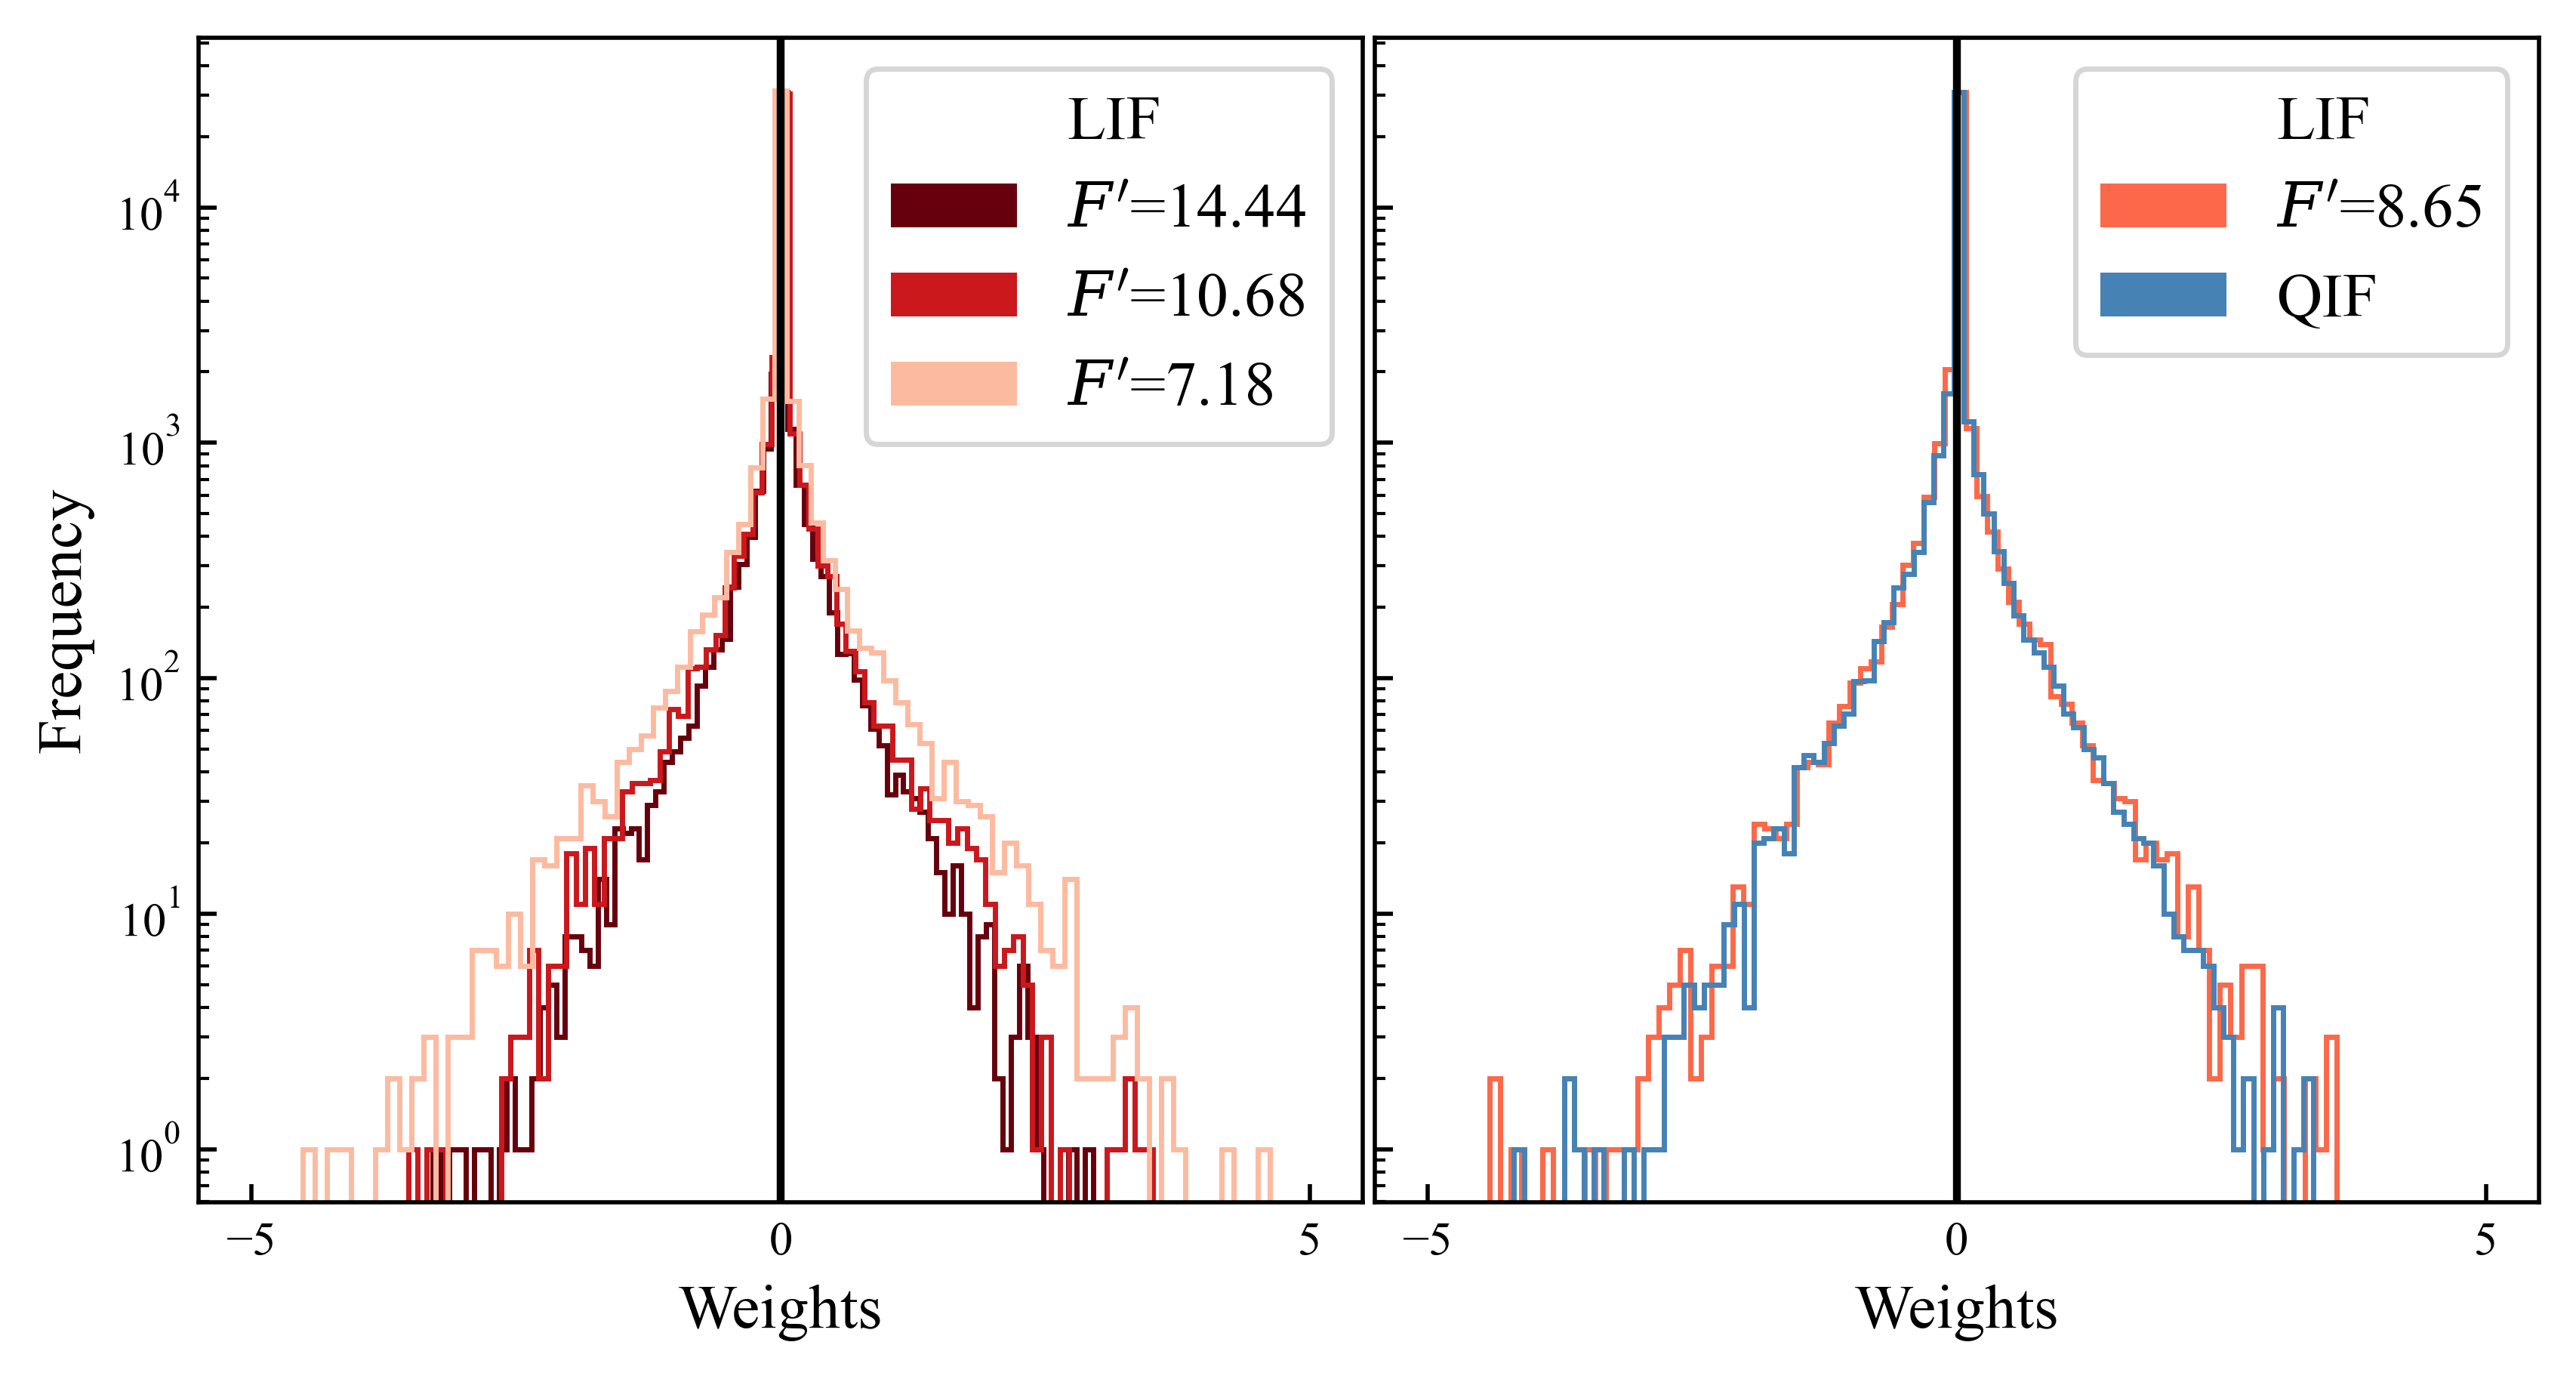

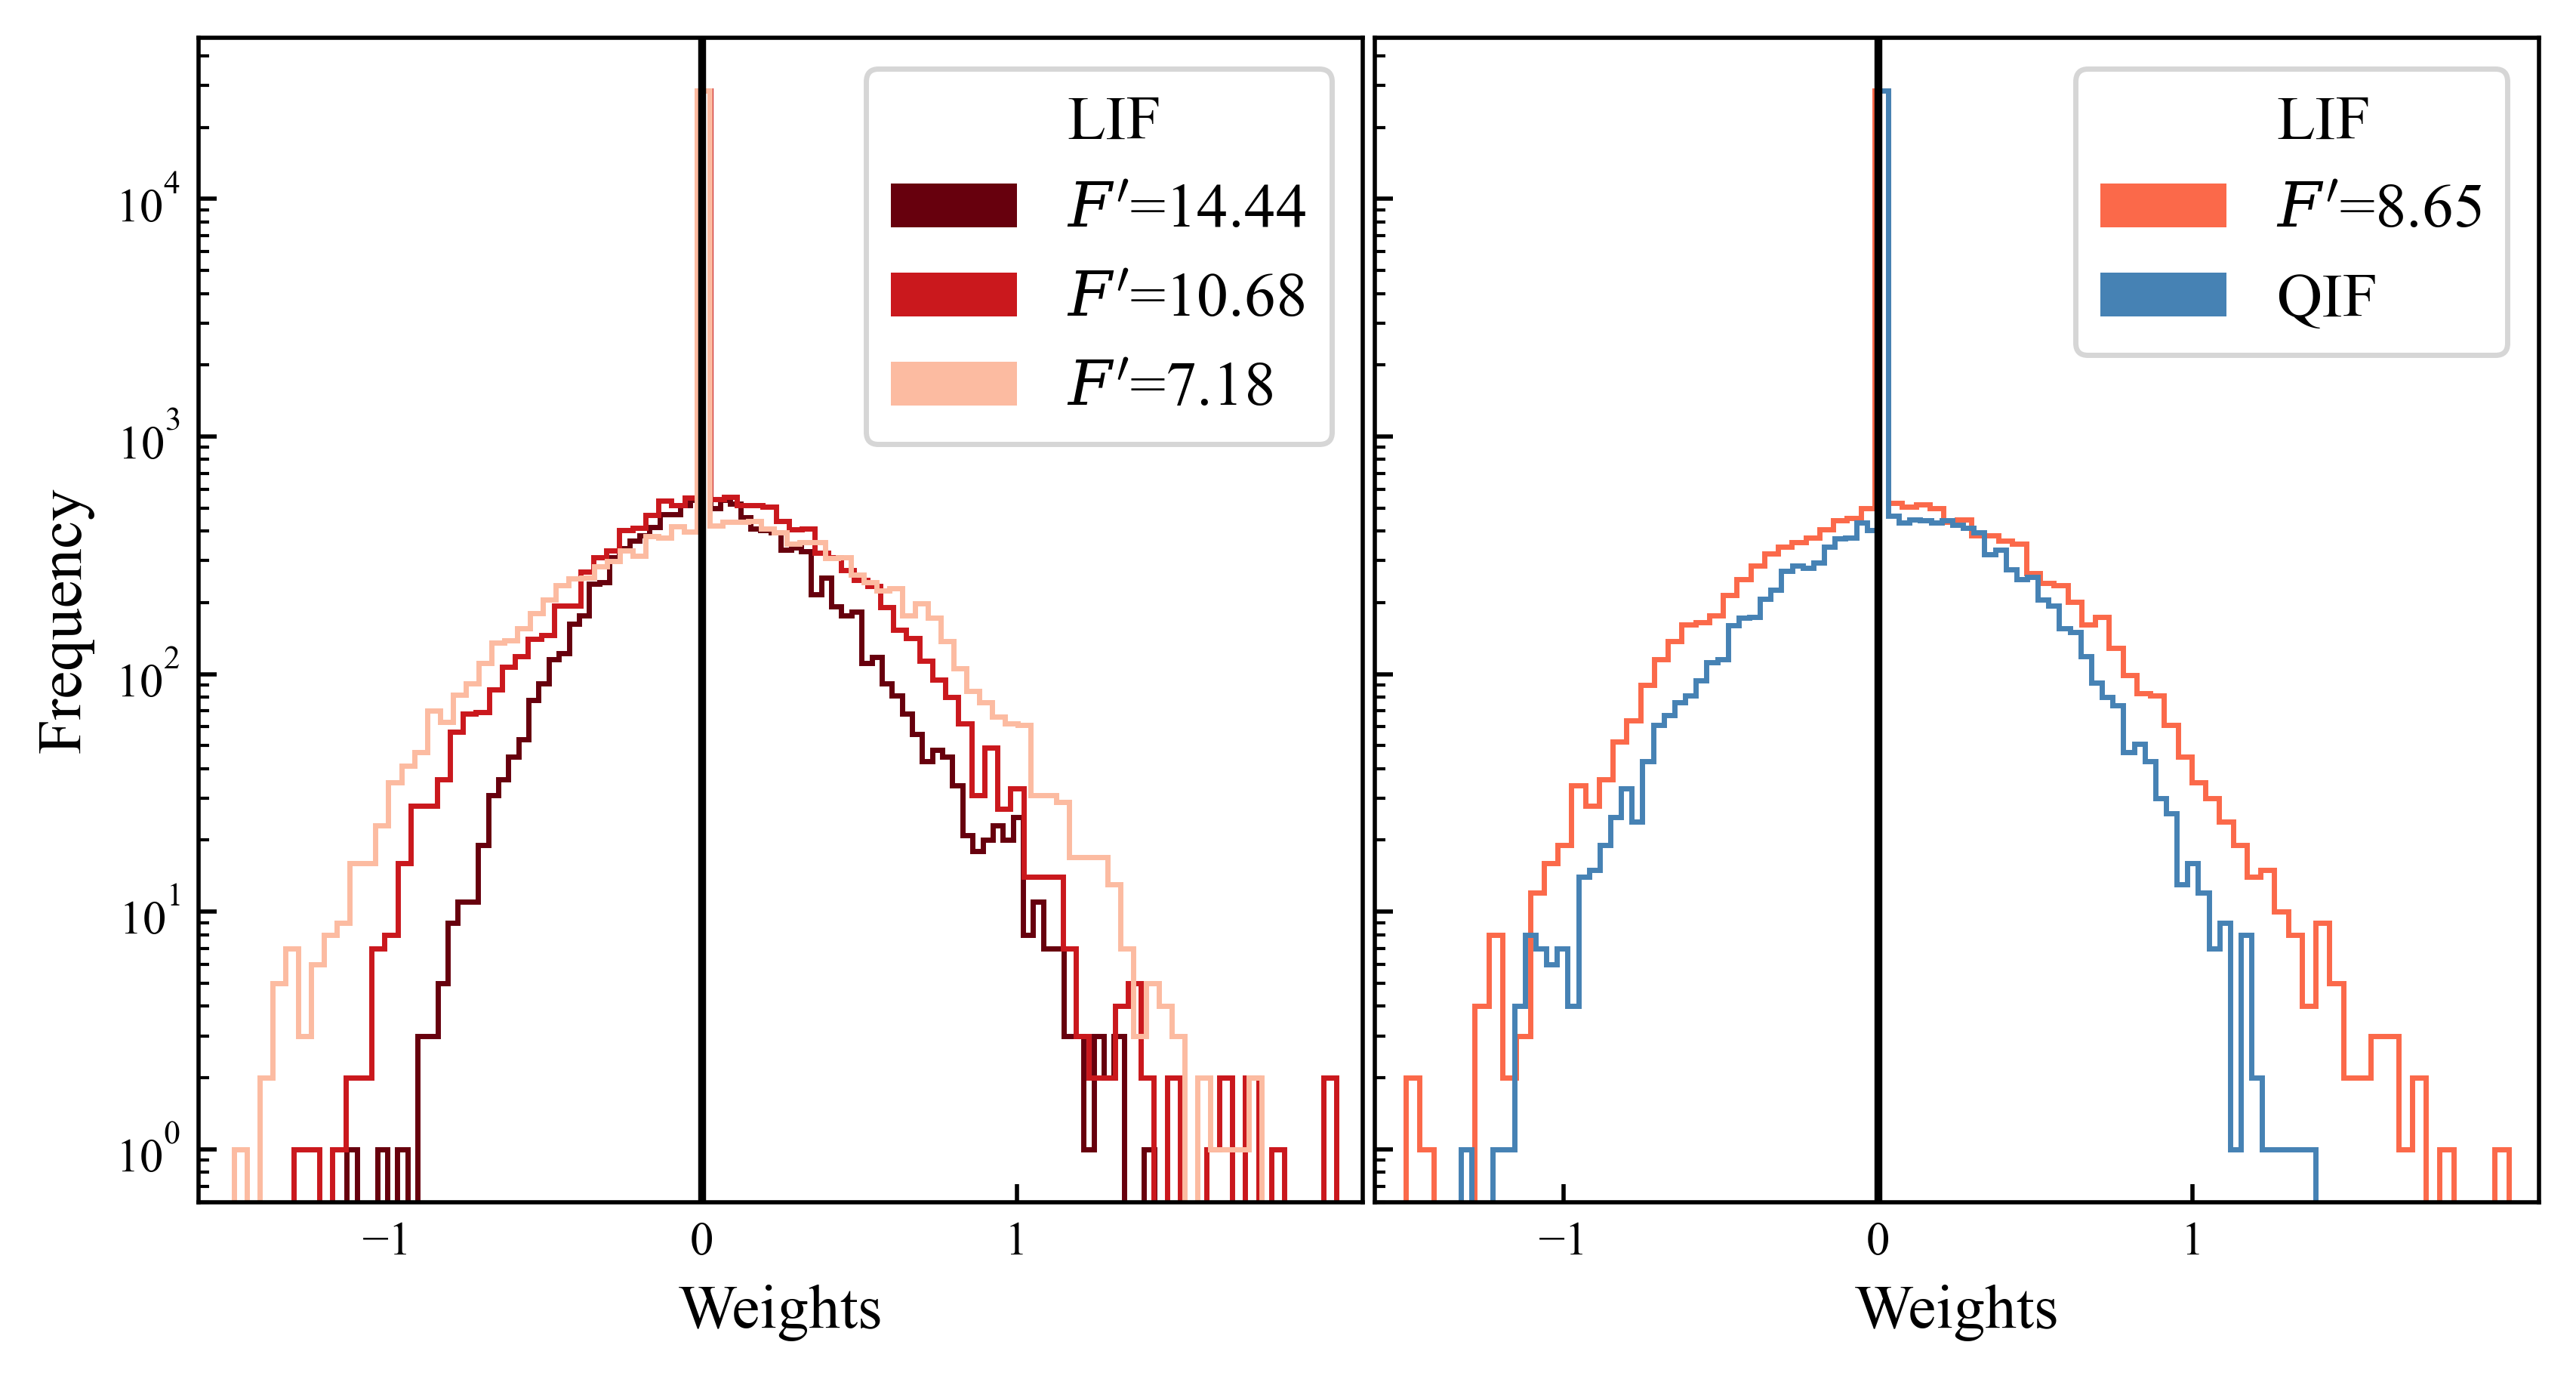

,dyn,permutated?,sim,f,pqif,std,mean
0,sequences,permutated,9,14.44,0,0.171910,0.015534
1,sequences,permutated,9,14.44,1,0.205844,0.021914
2,sequences,permutated,10,10.68,0,0.206964,0.017837
3,sequences,permutated,10,10.68,1,0.211557,0.021865
4,sequences,permutated,11,8.65,0,0.233942,0.020025
5,sequences,permutated,11,8.65,1,0.201524,0.022247
6,sequences,permutated,12,7.18,0,0.251689,0.021813
7,sequences,permutated,12,7.18,1,0.189763,0.022430


In [69]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random
from matplotlib.patches import Patch


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']

# seed_number = [i for i in range(0, 1)] # Only use one seed for this
# seed_number = [random.randint(1, 49)]
seed_number = [2] 
print(f"Used seed {seed_number}")

rows = []

########## Figure loop ##########
for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    # if dyn == 'oscillations':
    #     simulation_number = [i for i in range(1,5)]
    # elif dyn == 'sequences':
    #     simulation_number = [i for i in range(9, 13)]
    # else:
    #     print('Invalid dynamics')
    #     sys.exit()

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]
    # simulation_number, vrest, slope = ([1], [-8.5], [14.44])  if dyn == 'oscillations' else ([9], [-8.5], [14.44])

    figname = f"{dyn}_homogenous_histo_weights.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        # figsize=(10,4),  # TODO review
        sharey=True
    )

    fig.subplots_adjust(
    wspace=0.01
)

    # fig, (ax1, ax2) = plt.subplots(
    #     figsize=(16, 10),
    #     nrows=1, ncols=2
    # )

    # ax_map = {
    #     'A': axes[0],
    #     'B': axes[1],
    # }

    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                #### Take out values to plot

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

                ID = df_filtered['simulationID'].item()  # Simulation ID

                current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                current_weights = current_weights_noflatten.flatten()

                std = current_weights.std()
                mn = current_weights.mean()

                if dyn == 'sequences':
                    rows.append([dyn, "permutated", sim, f, pqif, std, mn])



                #### Color control flow
                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]



                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left
                # if pqif == 0 and f in slope:  # Left
                # if pqif == 0 and f in [14.44]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax1.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)

                    
                elif f == 8.65:  # Right
                # elif pqif == 1 and sim == simulation_number[2]:
                # if sim == simulation_number[2]:
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)


                else:  # Ignore others
                    continue


    #### Shared formatting
    # plt.suptitle(f"{dyn.capitalize()}")
    # plt.suptitle(f"Weight distribution ({dyn.capitalize()})")
    # plt.suptitle(f"Weight distribution")

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
        xlim = (-5.5, 5.5)
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]
        # xlim = (-1.6, 1.6)
        # xlim = (-2, 2)
        xlim = (-1.6, 2.1)

    for ax in (ax1, ax2):
        # ax.legend(loc='upper right')
        ax.set_xlabel("Weights")
        # ax.set_ylabel("Frequency")
        ax.axvline(0, color="black")
        ax.set_xticks(tick_positions)
        ax.set_xlim(xlim)
        ax.set_box_aspect(1)
    ax1.set_ylabel("Frequency")


    #### Custom legend

    legend_handles = []
    legend_labels = []
    slope = slope
    vrest = [-8.5, -12.3, -17, -22]

    # Legend for ax1 
    handles1 = []
    labels1 = []
    handles1.append(Patch(facecolor='none', edgecolor='none'))
    labels1.append("LIF")
    for vr, f in zip(vrest, slope):
        if f in [14.44, 10.68, 7.18]:
            handles1.append(Patch(facecolor=color_map_vrest[vr], edgecolor='none'))
            labels1.append(f"$F'$={f}")

    ax1.legend(handles1, labels1, frameon=True)

    # Legend for ax2    
    handles2 = []
    labels2 = []
    handles2.append(Patch(facecolor='none', edgecolor='none'))
    labels2.append("LIF")
    
    for vr, f in zip(vrest, slope):
        if f in [8.65]:
            handles2.append(Patch(facecolor=color_map_vrest[vr], edgecolor='none'))
            labels2.append(f"$F'$={f}")
    handles2.append(Patch(facecolor='steelblue', edgecolor='none'))
    labels2.append("QIF")

    ax2.legend(handles2, labels2, frameon=True)

    
    #### Save
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")

    # plt.tight_layout()
    plt.show()

cols = ["dyn", "permutated?", "sim", "f", "pqif", "std", "mean"]

stats_newversion = pd.DataFrame(rows, columns=cols)

display(stats_newversion)

## Separated 

In [ ]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random
from matplotlib.patches import Patch


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']

seed_number = [random.randint(1, 49)]
print(f"Used seed {seed_number}")


########## Figure loop ##########
for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    figname = f"{dyn}_homogenous_histo_weights_{}.svg"

    #### Create figure and axes



    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                #### Take out values to plot
                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata
                ID = df_filtered['simulationID'].item()  # Simulation ID
                current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                current_weights = current_weights_noflatten.flatten()
                std = current_weights.std()
                mn = current_weights.mean()

                #### Color control flow
                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]

                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)




                    
                elif f == 8.65:  # Right
                # elif pqif == 1 and sim == simulation_number[2]:
                # if sim == simulation_number[2]:
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)


                else:  # Ignore others
                    continue


    #### Shared formatting

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
        xlim = (-5.5, 5.5)
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]
        xlim = (-1.6, 1.6)

    for ax in (ax1, ax2):
        # ax.legend(loc='upper right')
        ax.set_xlabel("Weights")
        # ax.set_ylabel("Frequency")
        ax.axvline(0, color="black")
        ax.set_xticks(tick_positions)
        ax.set_xlim(xlim)
        ax.set_box_aspect(1)
    ax1.set_ylabel("Frequency")


    #### Custom legend

    legend_handles = []
    legend_labels = []
    slope = slope
    vrest = [-8.5, -12.3, -17, -22]

    # Legend for ax1 
    handles1 = []
    labels1 = []
    handles1.append(Patch(facecolor='none', edgecolor='none'))
    labels1.append("LIF")
    for vr, f in zip(vrest, slope):
        if f in [14.44, 10.68, 7.18]:
            handles1.append(Patch(facecolor=color_map_vrest[vr], edgecolor='none'))
            labels1.append(f"$F'$={f}")

    ax1.legend(handles1, labels1, frameon=True)

    # Legend for ax2    
    handles2 = []
    labels2 = []
    handles2.append(Patch(facecolor='none', edgecolor='none'))
    labels2.append("LIF")
    
    for vr, f in zip(vrest, slope):
        if f in [8.65]:
            handles2.append(Patch(facecolor=color_map_vrest[vr], edgecolor='none'))
            labels2.append(f"$F'$={f}")
    handles2.append(Patch(facecolor='steelblue', edgecolor='none'))
    labels2.append("QIF")

    ax2.legend(handles2, labels2, frameon=True)

    
    #### Save
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")

    # plt.tight_layout()
    plt.show()

cols = ["dyn", "permutated?", "sim", "f", "pqif", "std", "mean"]

stats_newversion = pd.DataFrame(rows, columns=cols)

display(stats_newversion)

# Std+Mean vs. F' homogenous networks

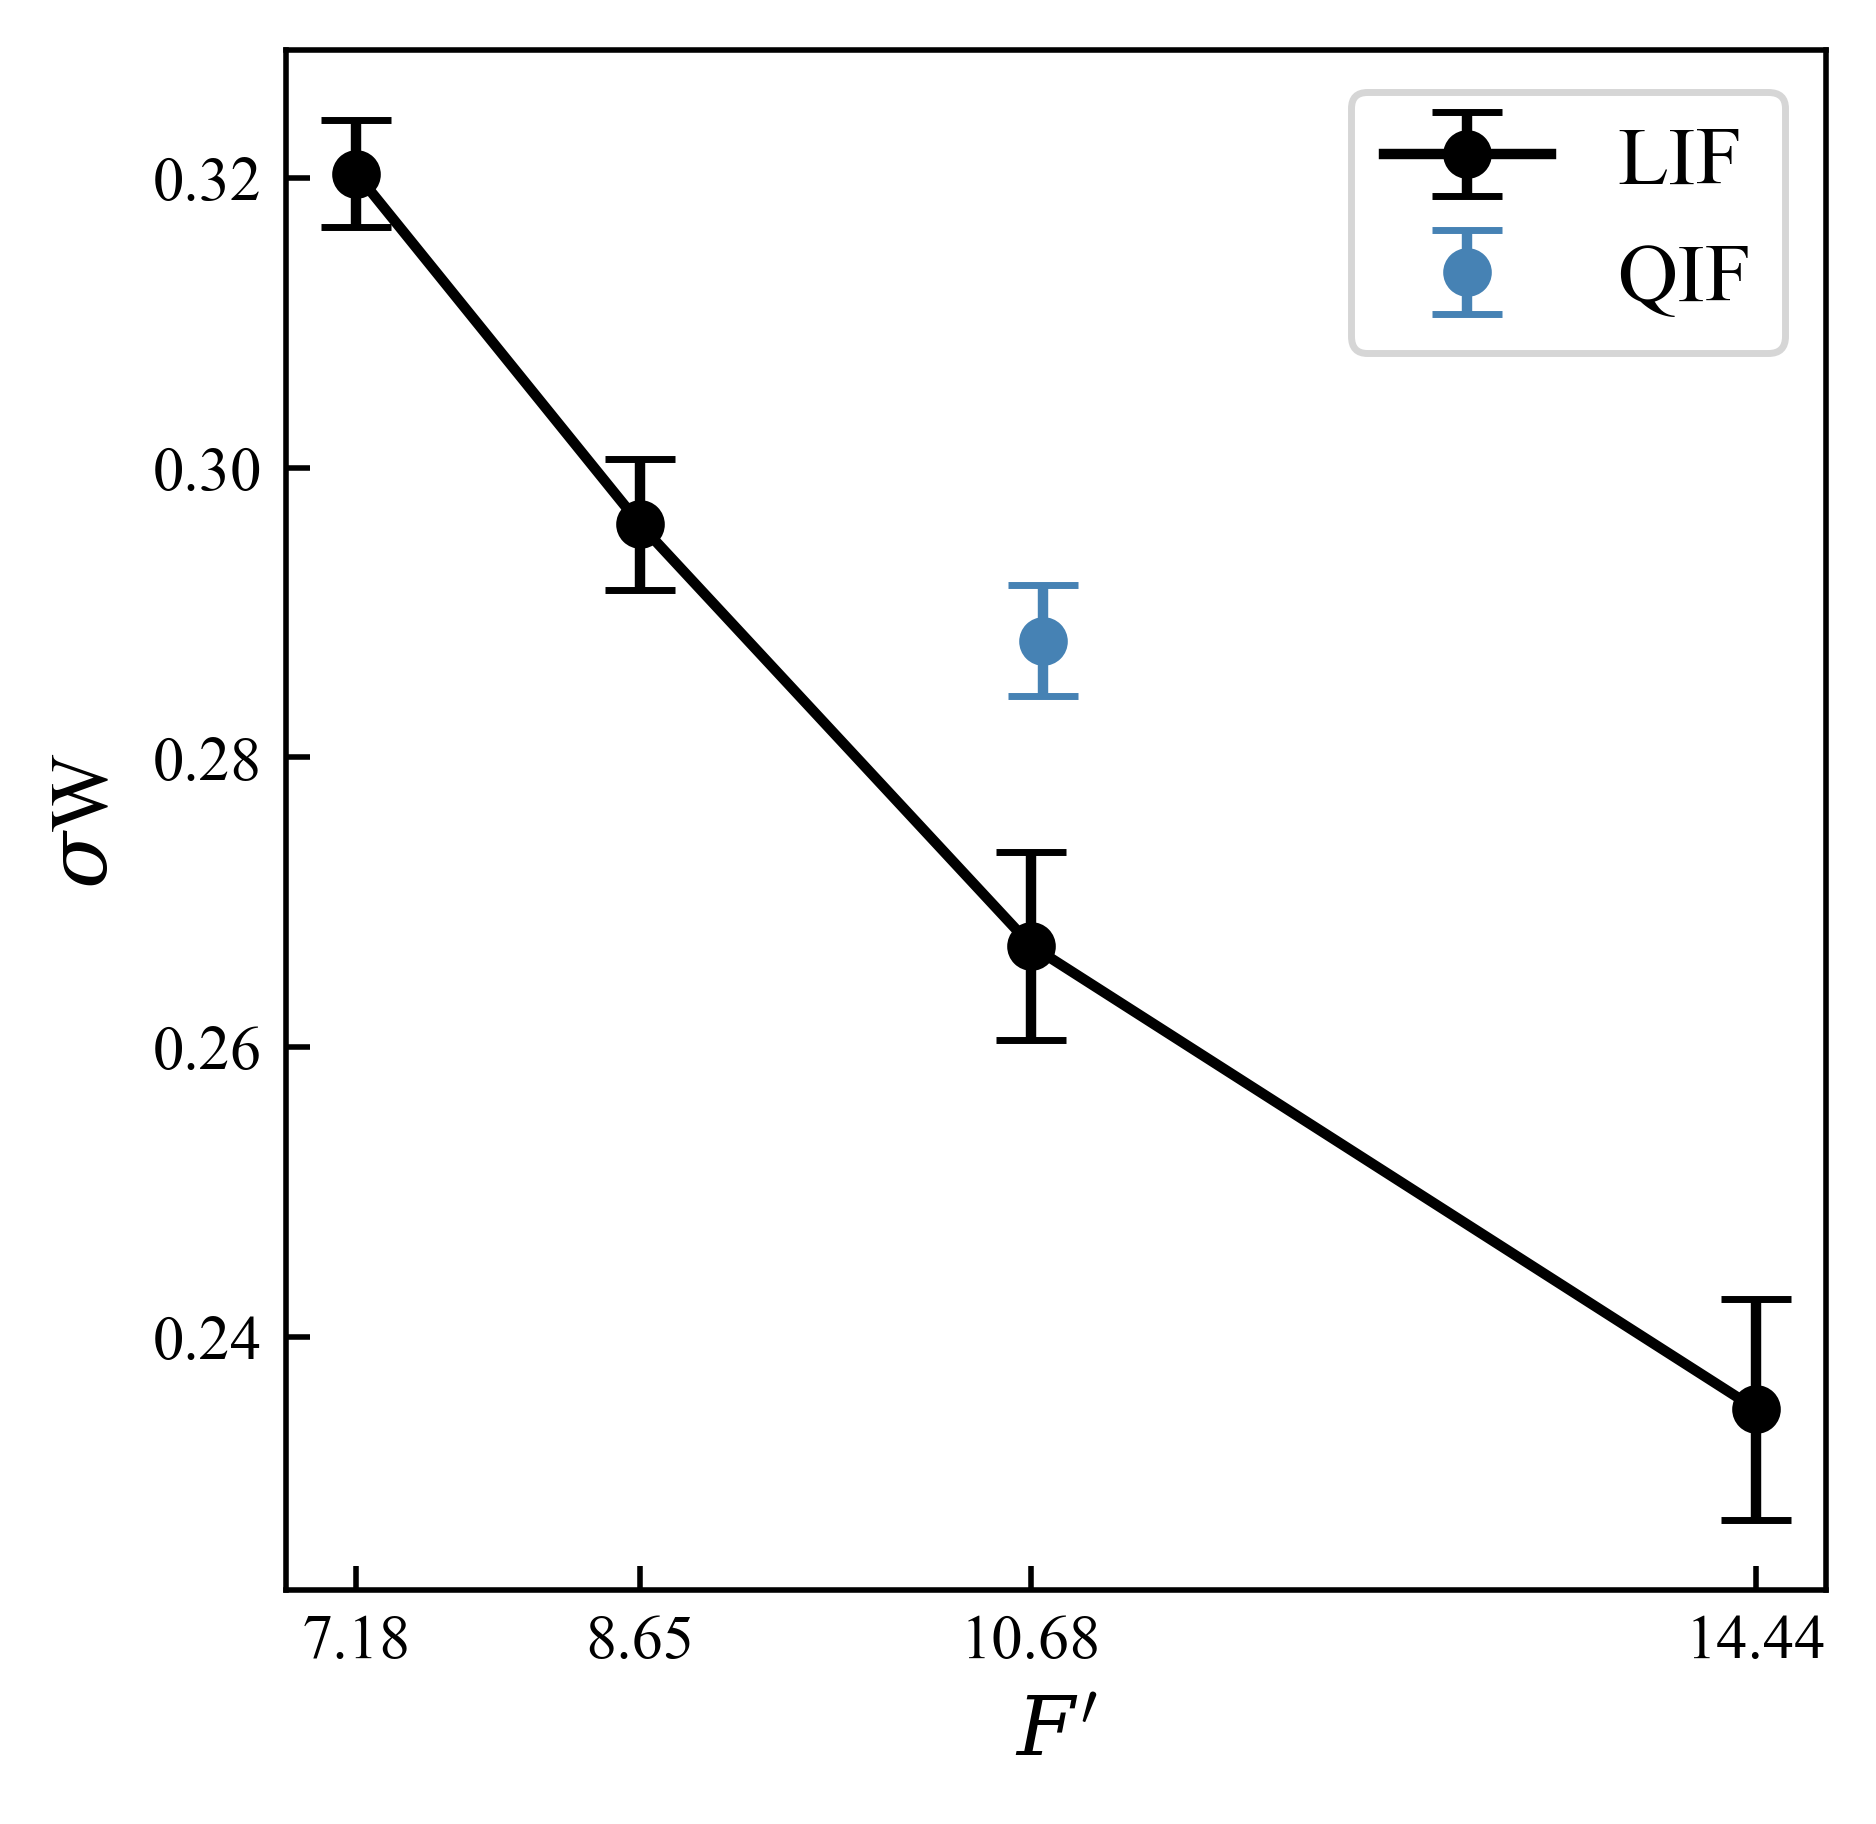

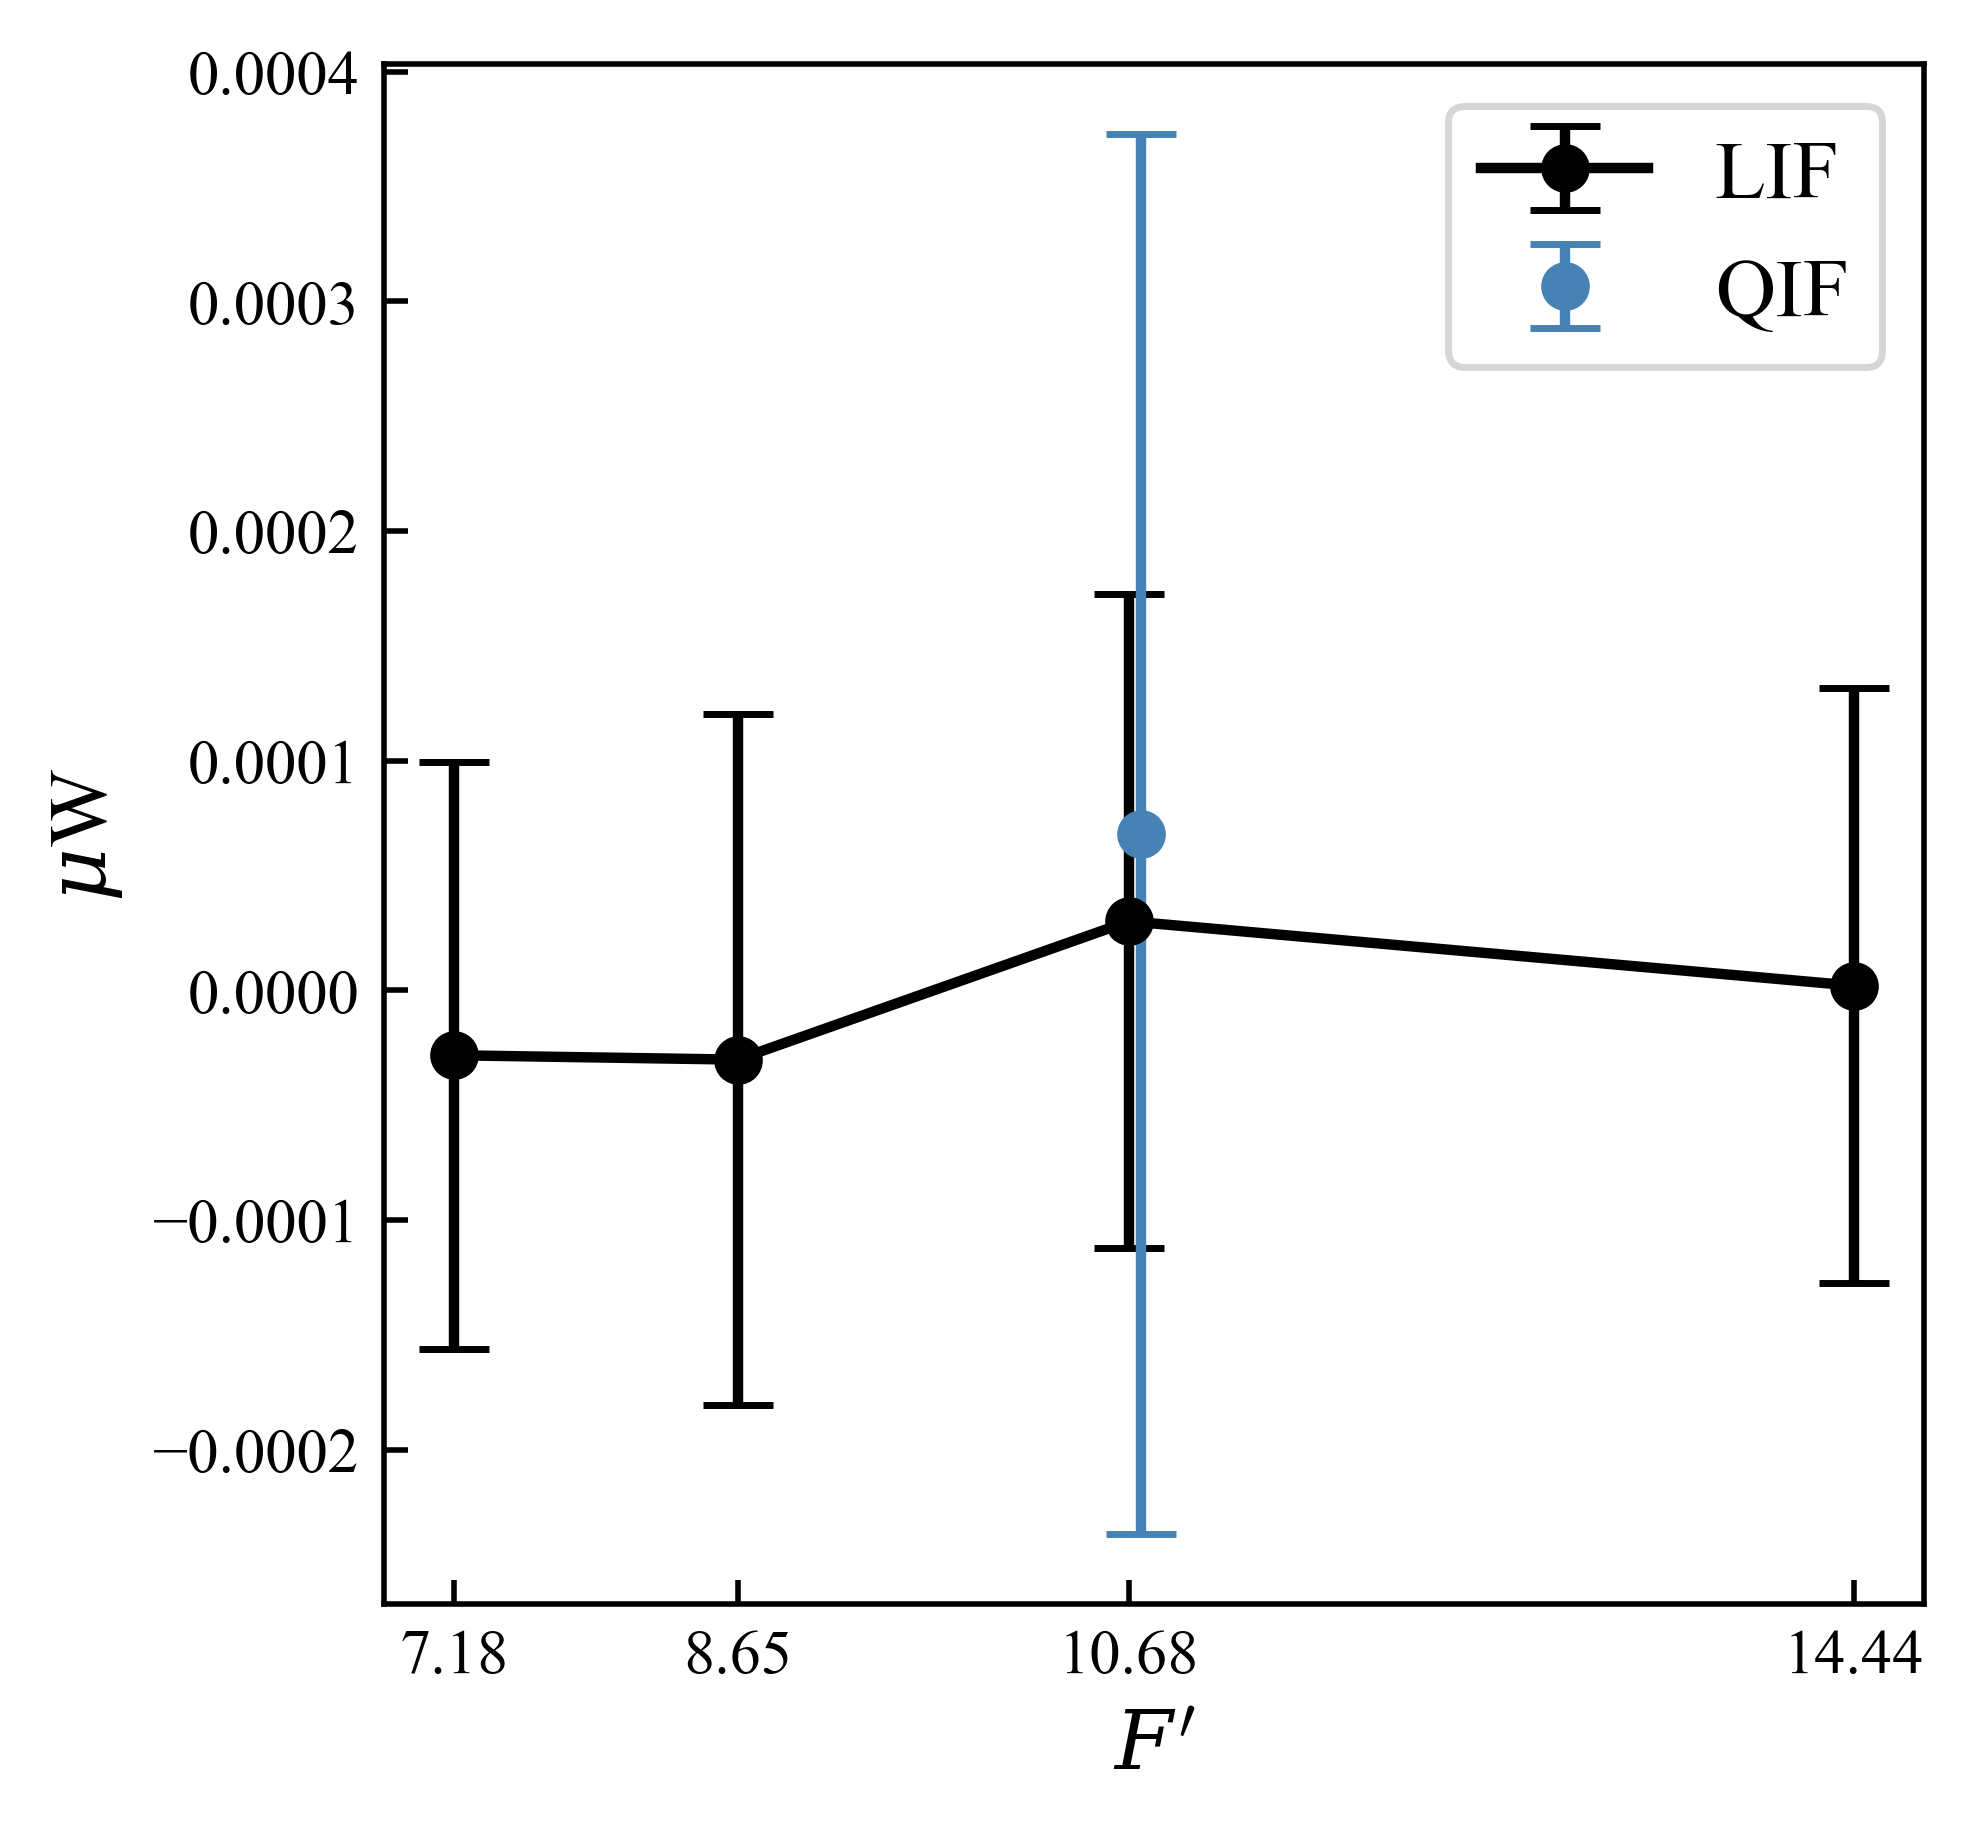

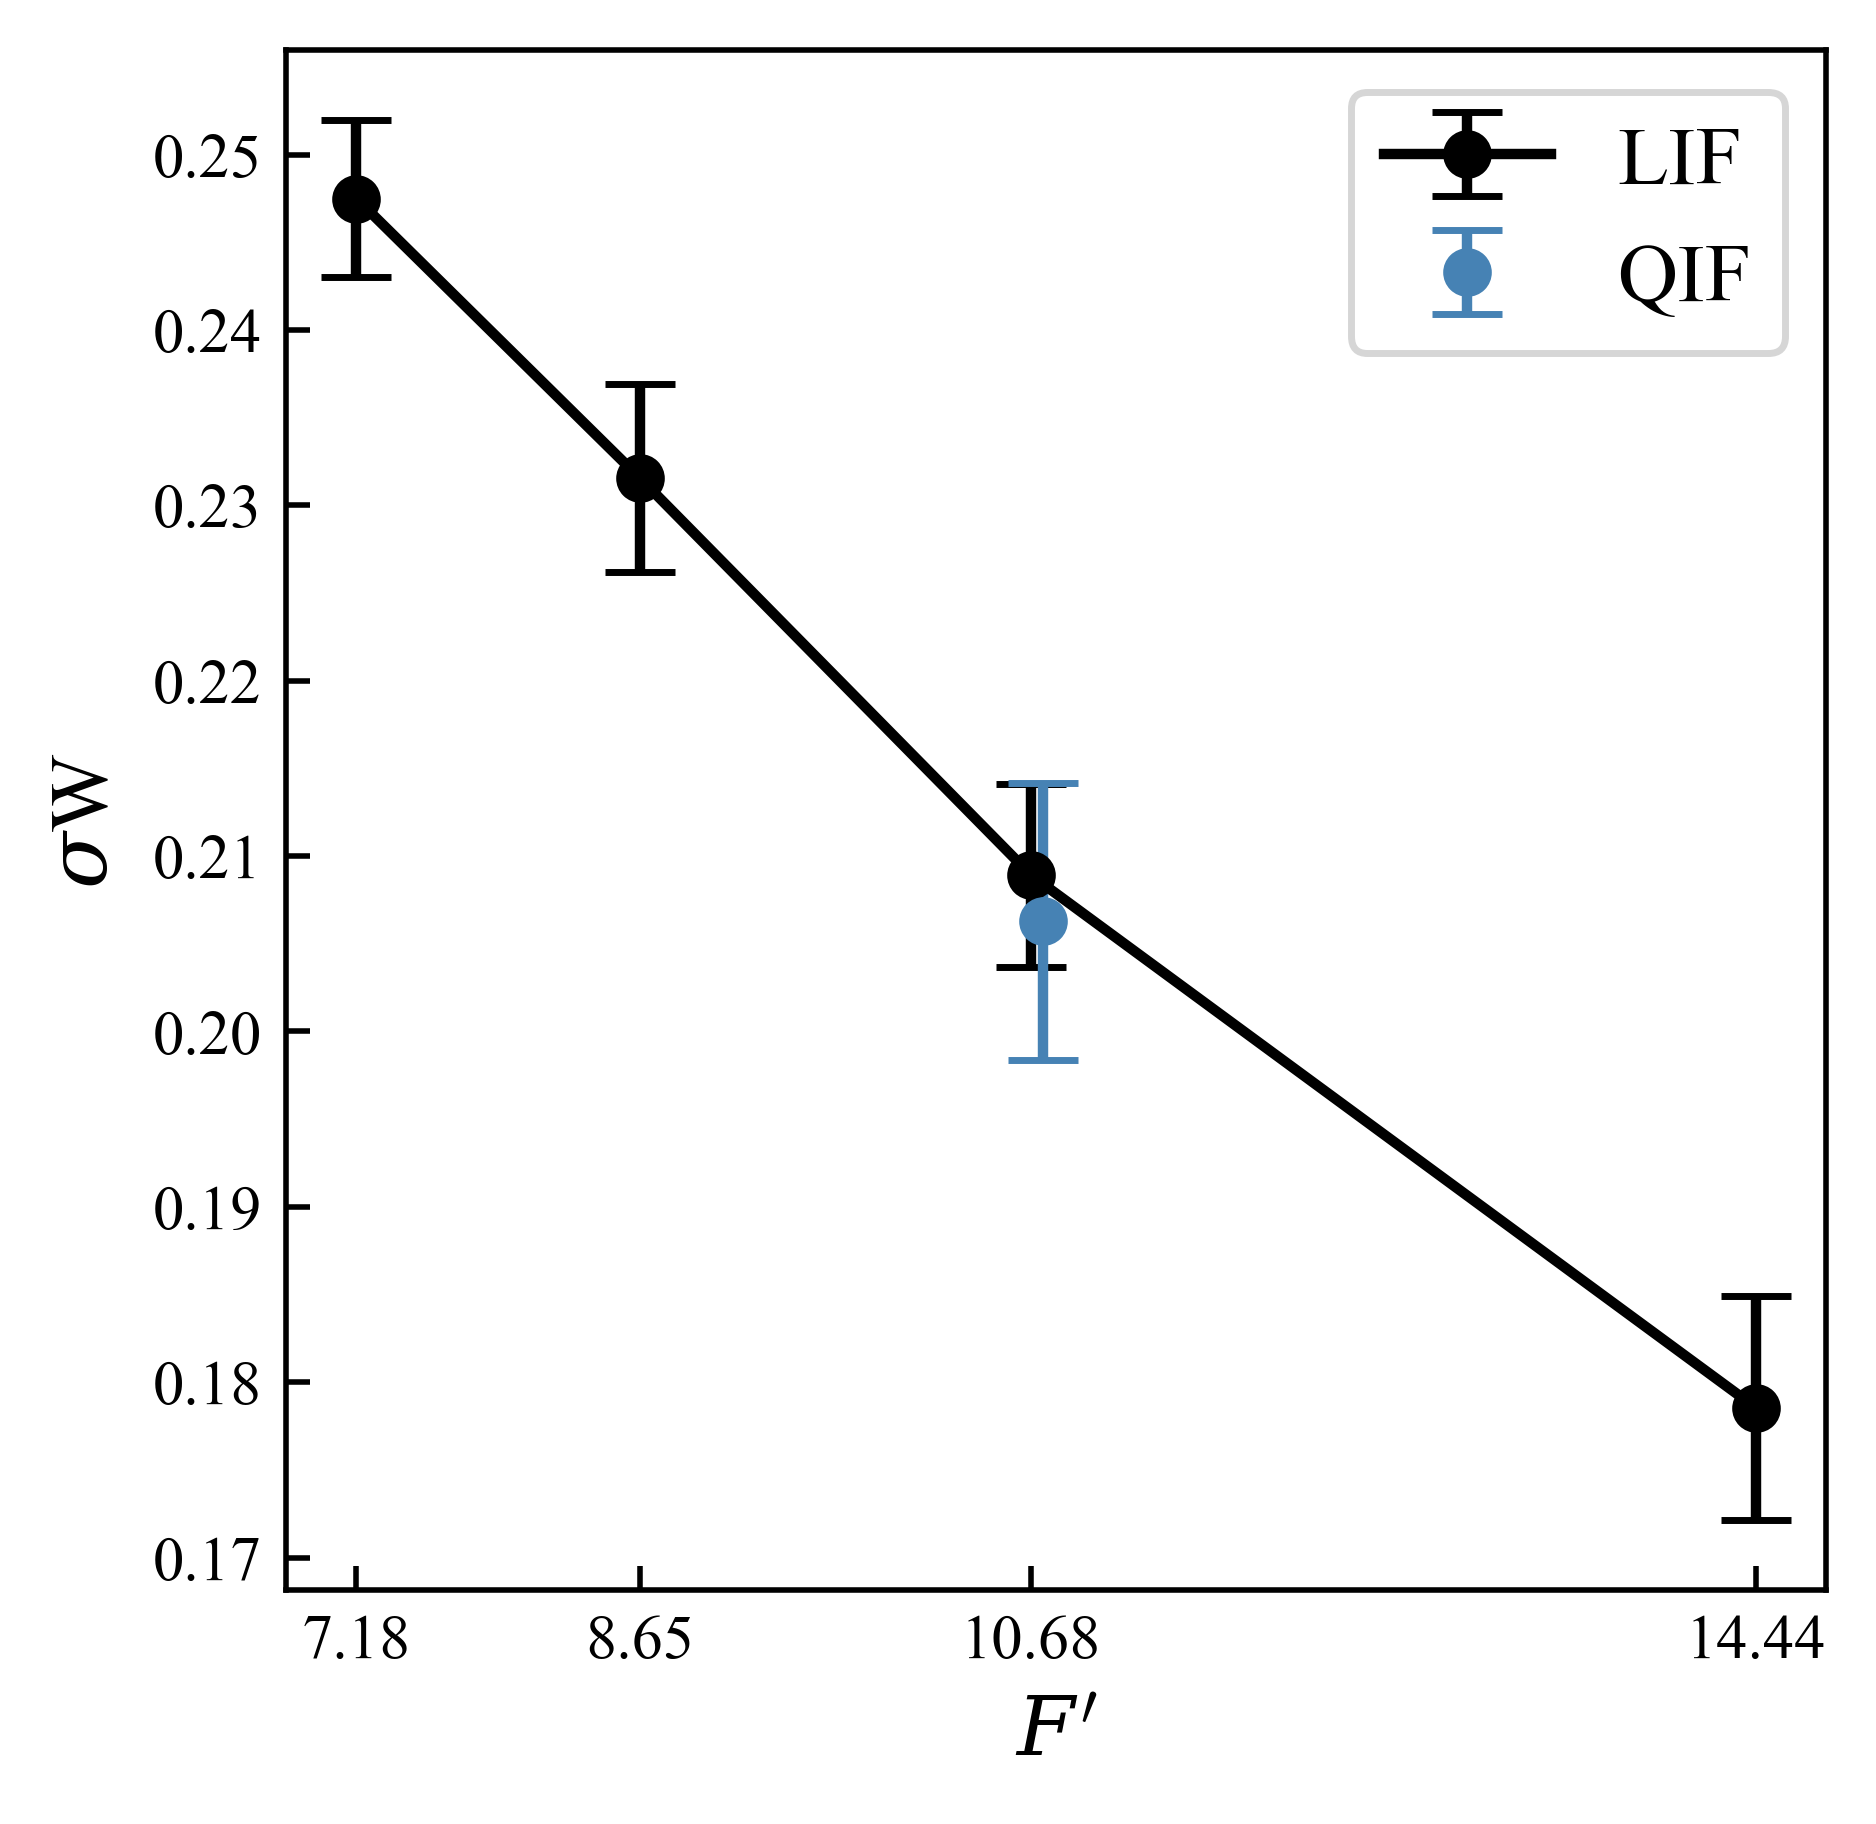

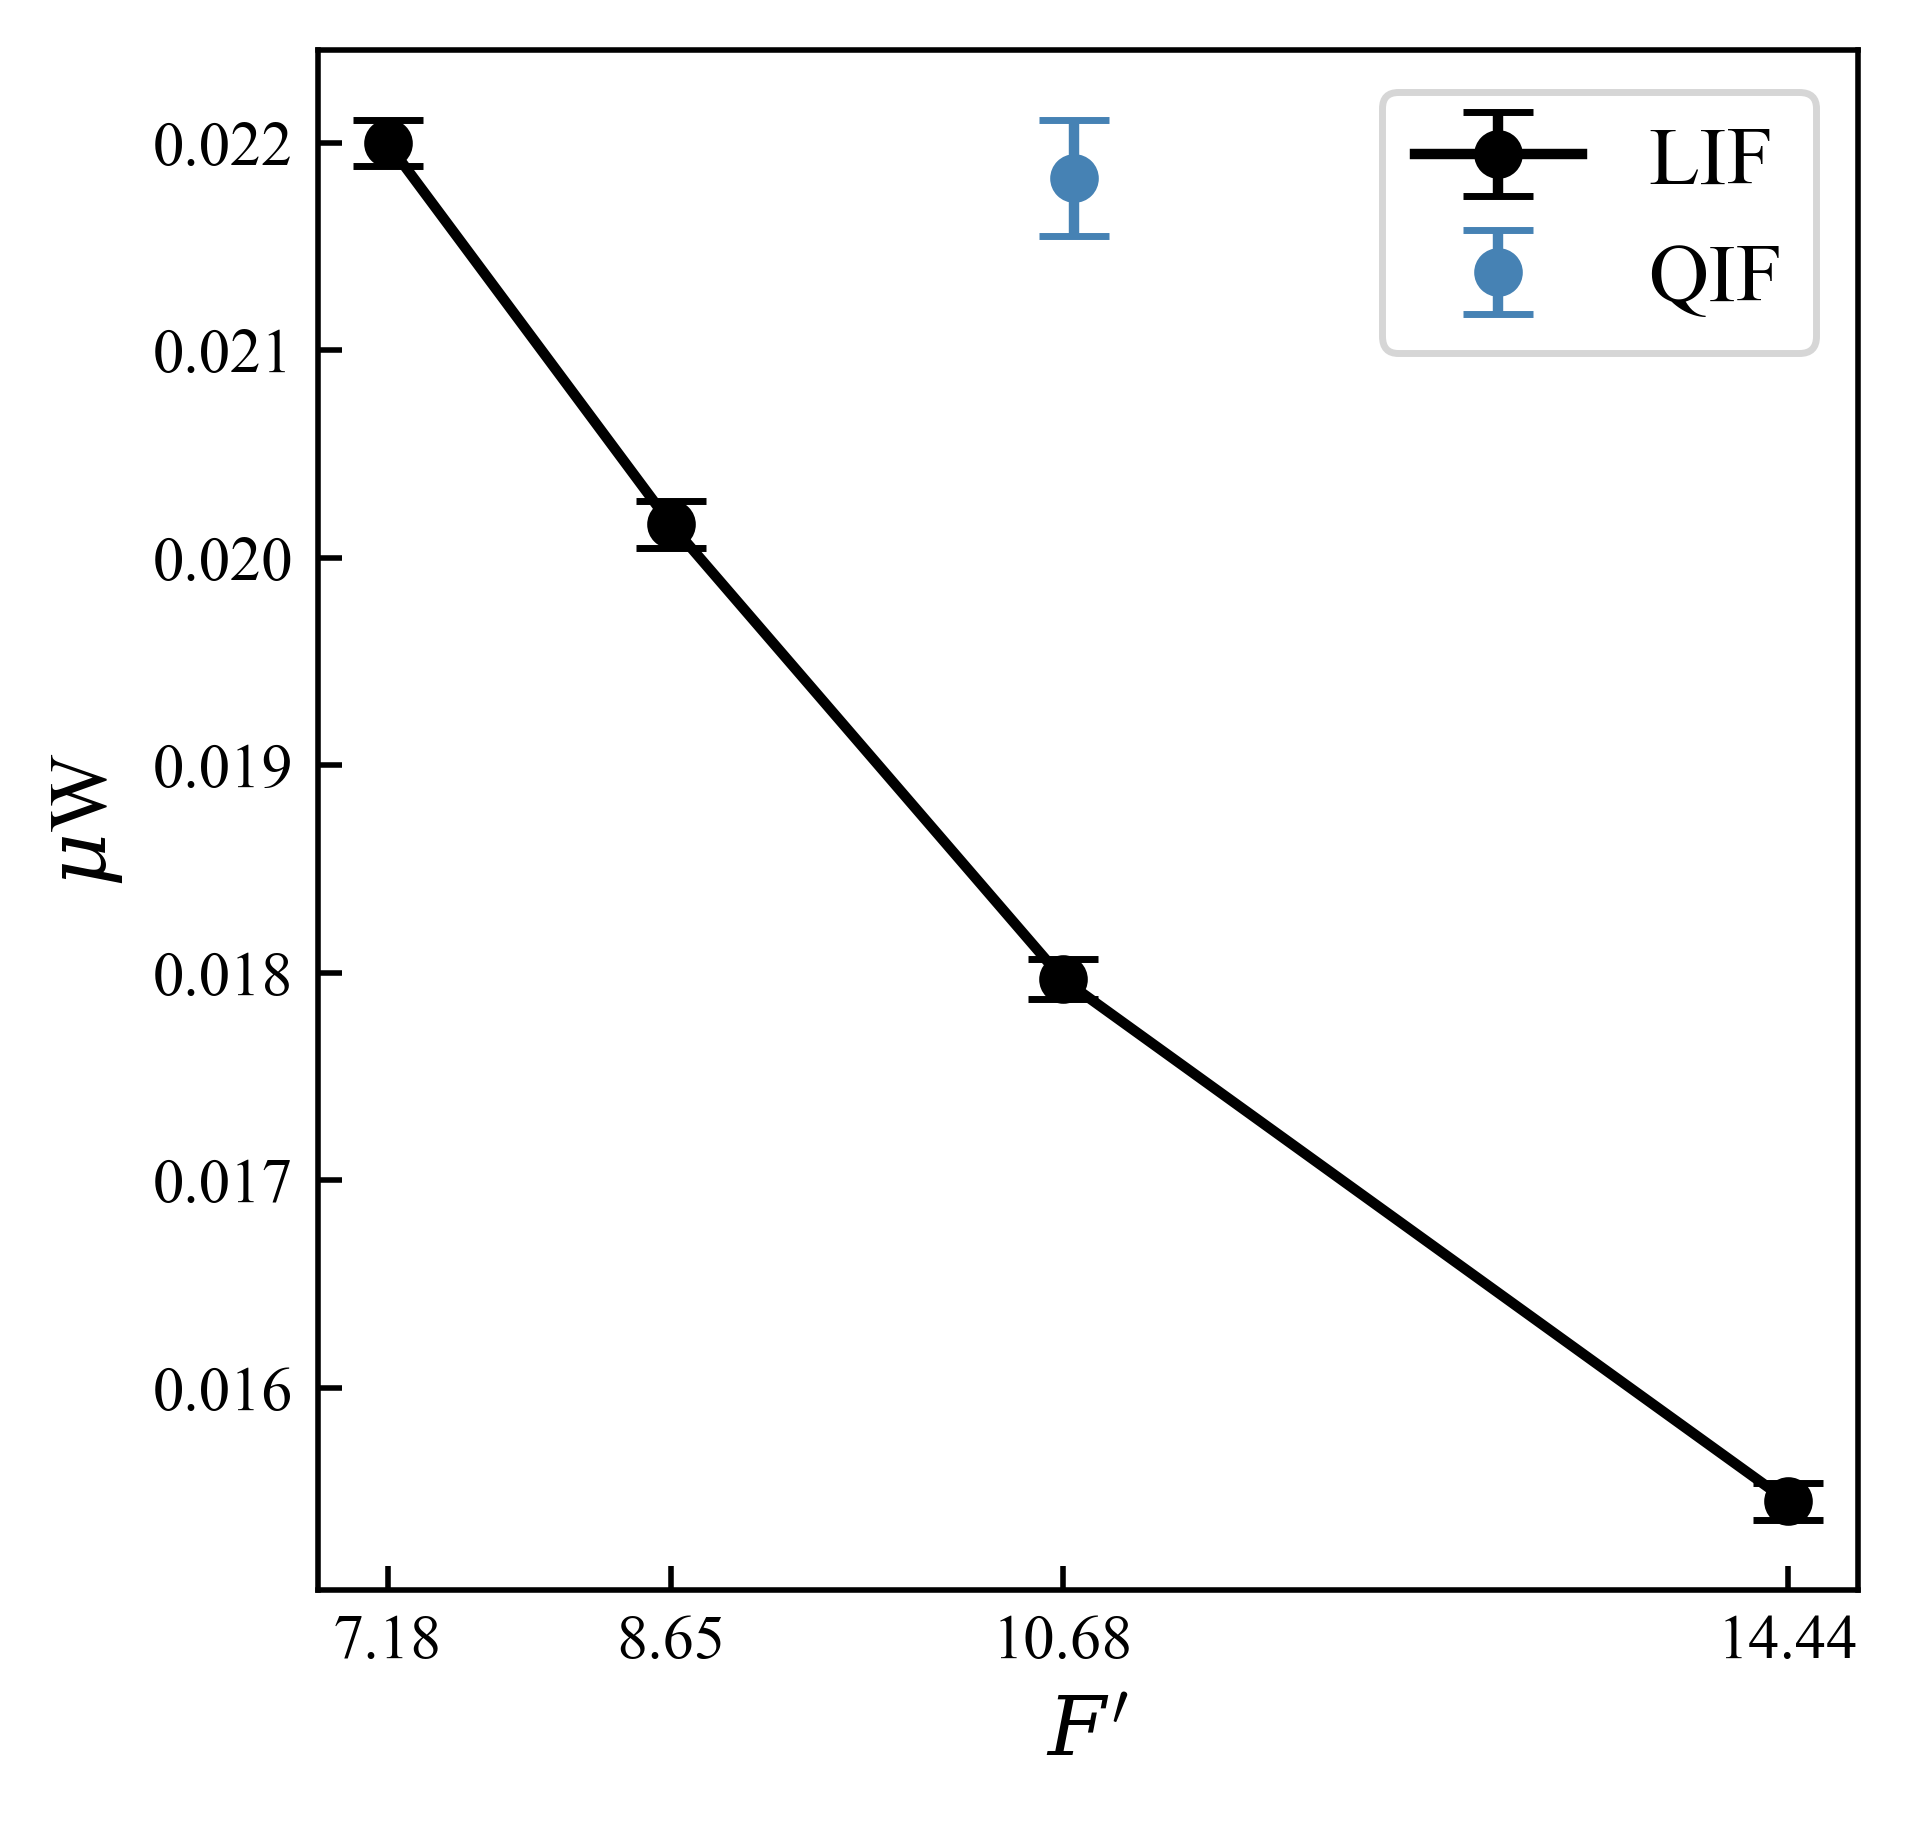

In [13]:
# ========== Standard deviation or Mean of weights vs. slope for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

columns = ['std', 'mean']

x_ticks = [14.44, 10.68, 8.65, 7.18]

########## Figure loop ##########

for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()


    #### Plot same figures for both STD and mean
    for c in columns:

        figname = f"{dyn}_homogenous_{c}-vs-slope.svg"
        fig, ax = plt.subplots(figsize=(6, 4))


        for pqif in pqif_homogenous:

            y = []
            yerr = []
            x = slope


            for sim, vr, f in zip(simulation_number, vrest, slope):

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()

                if pqif == 0: # For LIF: Make list across slope
                    y.append(y_i)
                    yerr.append(yerr_i)

                elif pqif == 1:  # Only one value for QIF since it is the same in each simulation
                    y = y_i
                    yerr = yerr_i

            colors = color_map_pqif[pqif]

            #### Title and labels depending on if STD or mean 

            if c == 'std':
                # title = f"$\sigma$W vs. $F'$, {dyn.capitalize()}"
                title = f"$\sigma$W vs. $F'$"
                xlabel = f"$F'$"
                ylabel = f"$\sigma$W"

            elif c == "mean":
                # title = f"$\mu$W vs. $F'$, {dyn.capitalize()}"
                title = f"$\mu$W vs. $F'$"
                xlabel = f"$F'$"
                ylabel = f"$\mu$W"

            #### Plot values on ax

            if pqif == 0:
                label = 'LIF'
                ax.errorbar(x, y, yerr, fmt='o-', capsize=5, color=colors, label=label)

            elif pqif == 1:
                label = 'QIF'
                ax.errorbar(slope_qif, y, yerr, fmt='o', capsize=5, color=colors, label=label)

        # ax.set_title(title)
        ax.set_xticks(x_ticks)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_box_aspect(1)
        # if c == "mean":
        #     ax.set_ylim(0, 0.024)
        plt.legend()
        full_path = os.path.join(figure_folder, figname)
        plt.savefig(full_path, format="svg")
        plt.show()



# Std+Mean vs. pqif for heterogenous networks

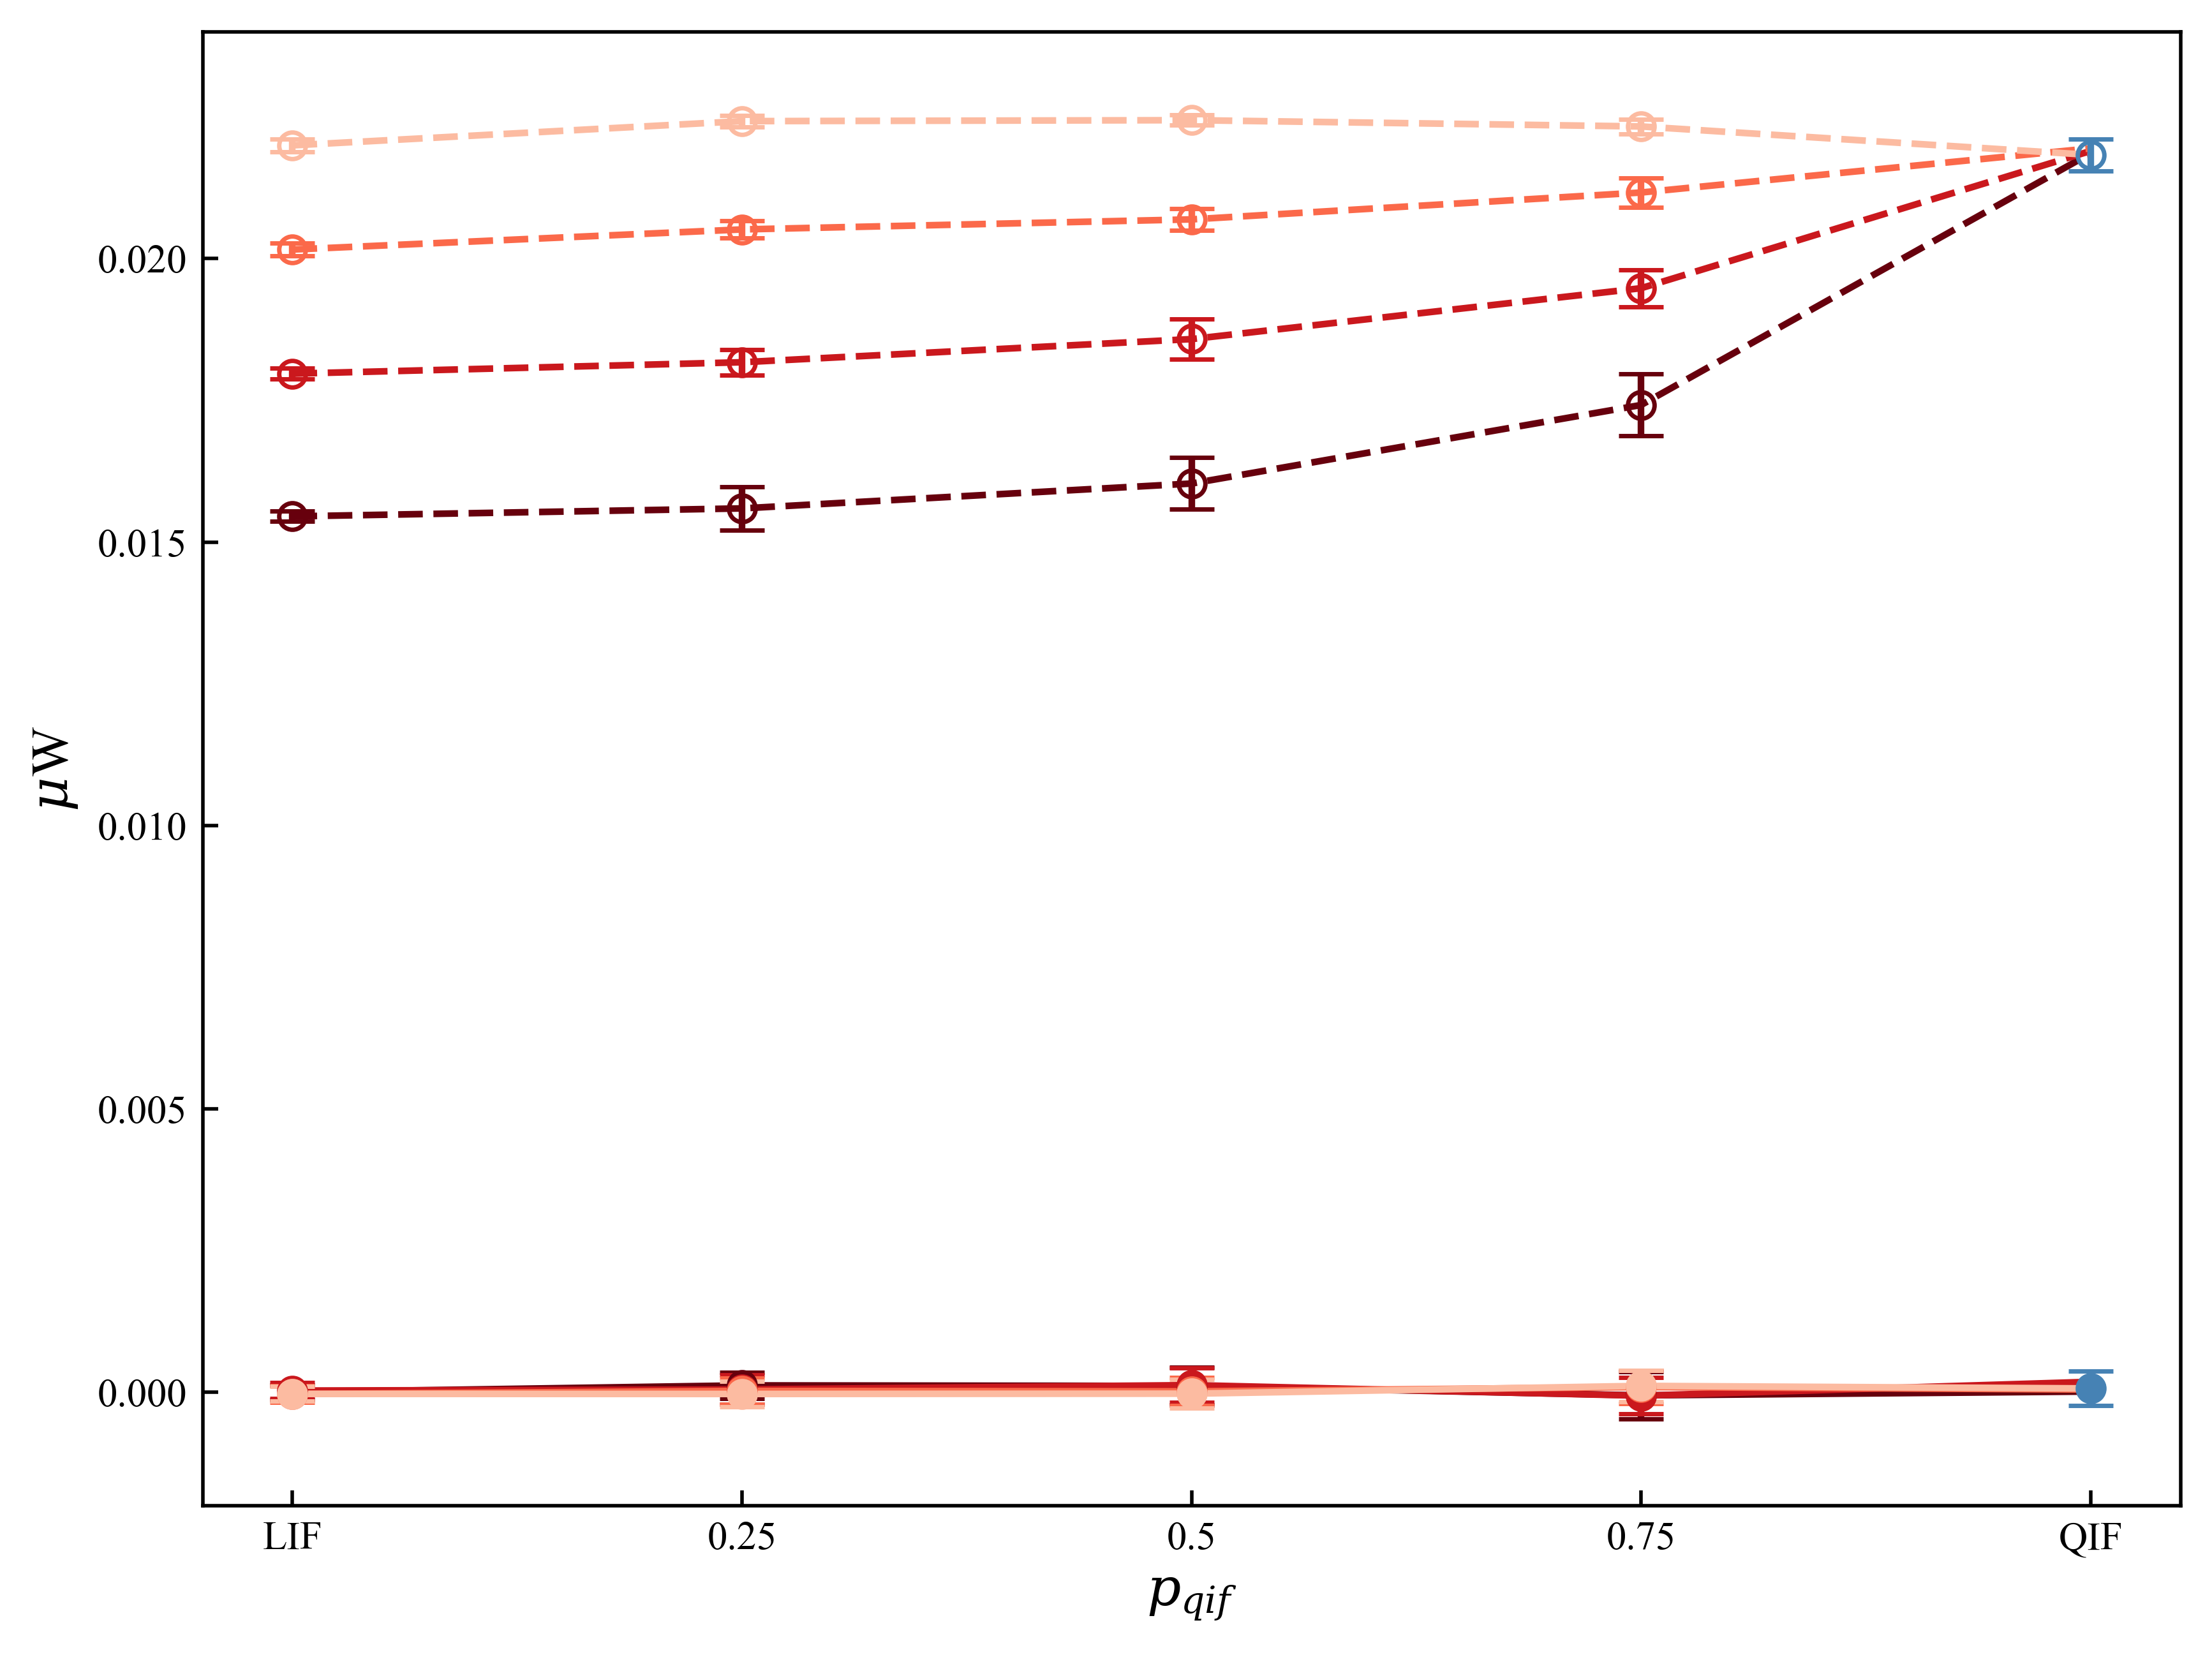

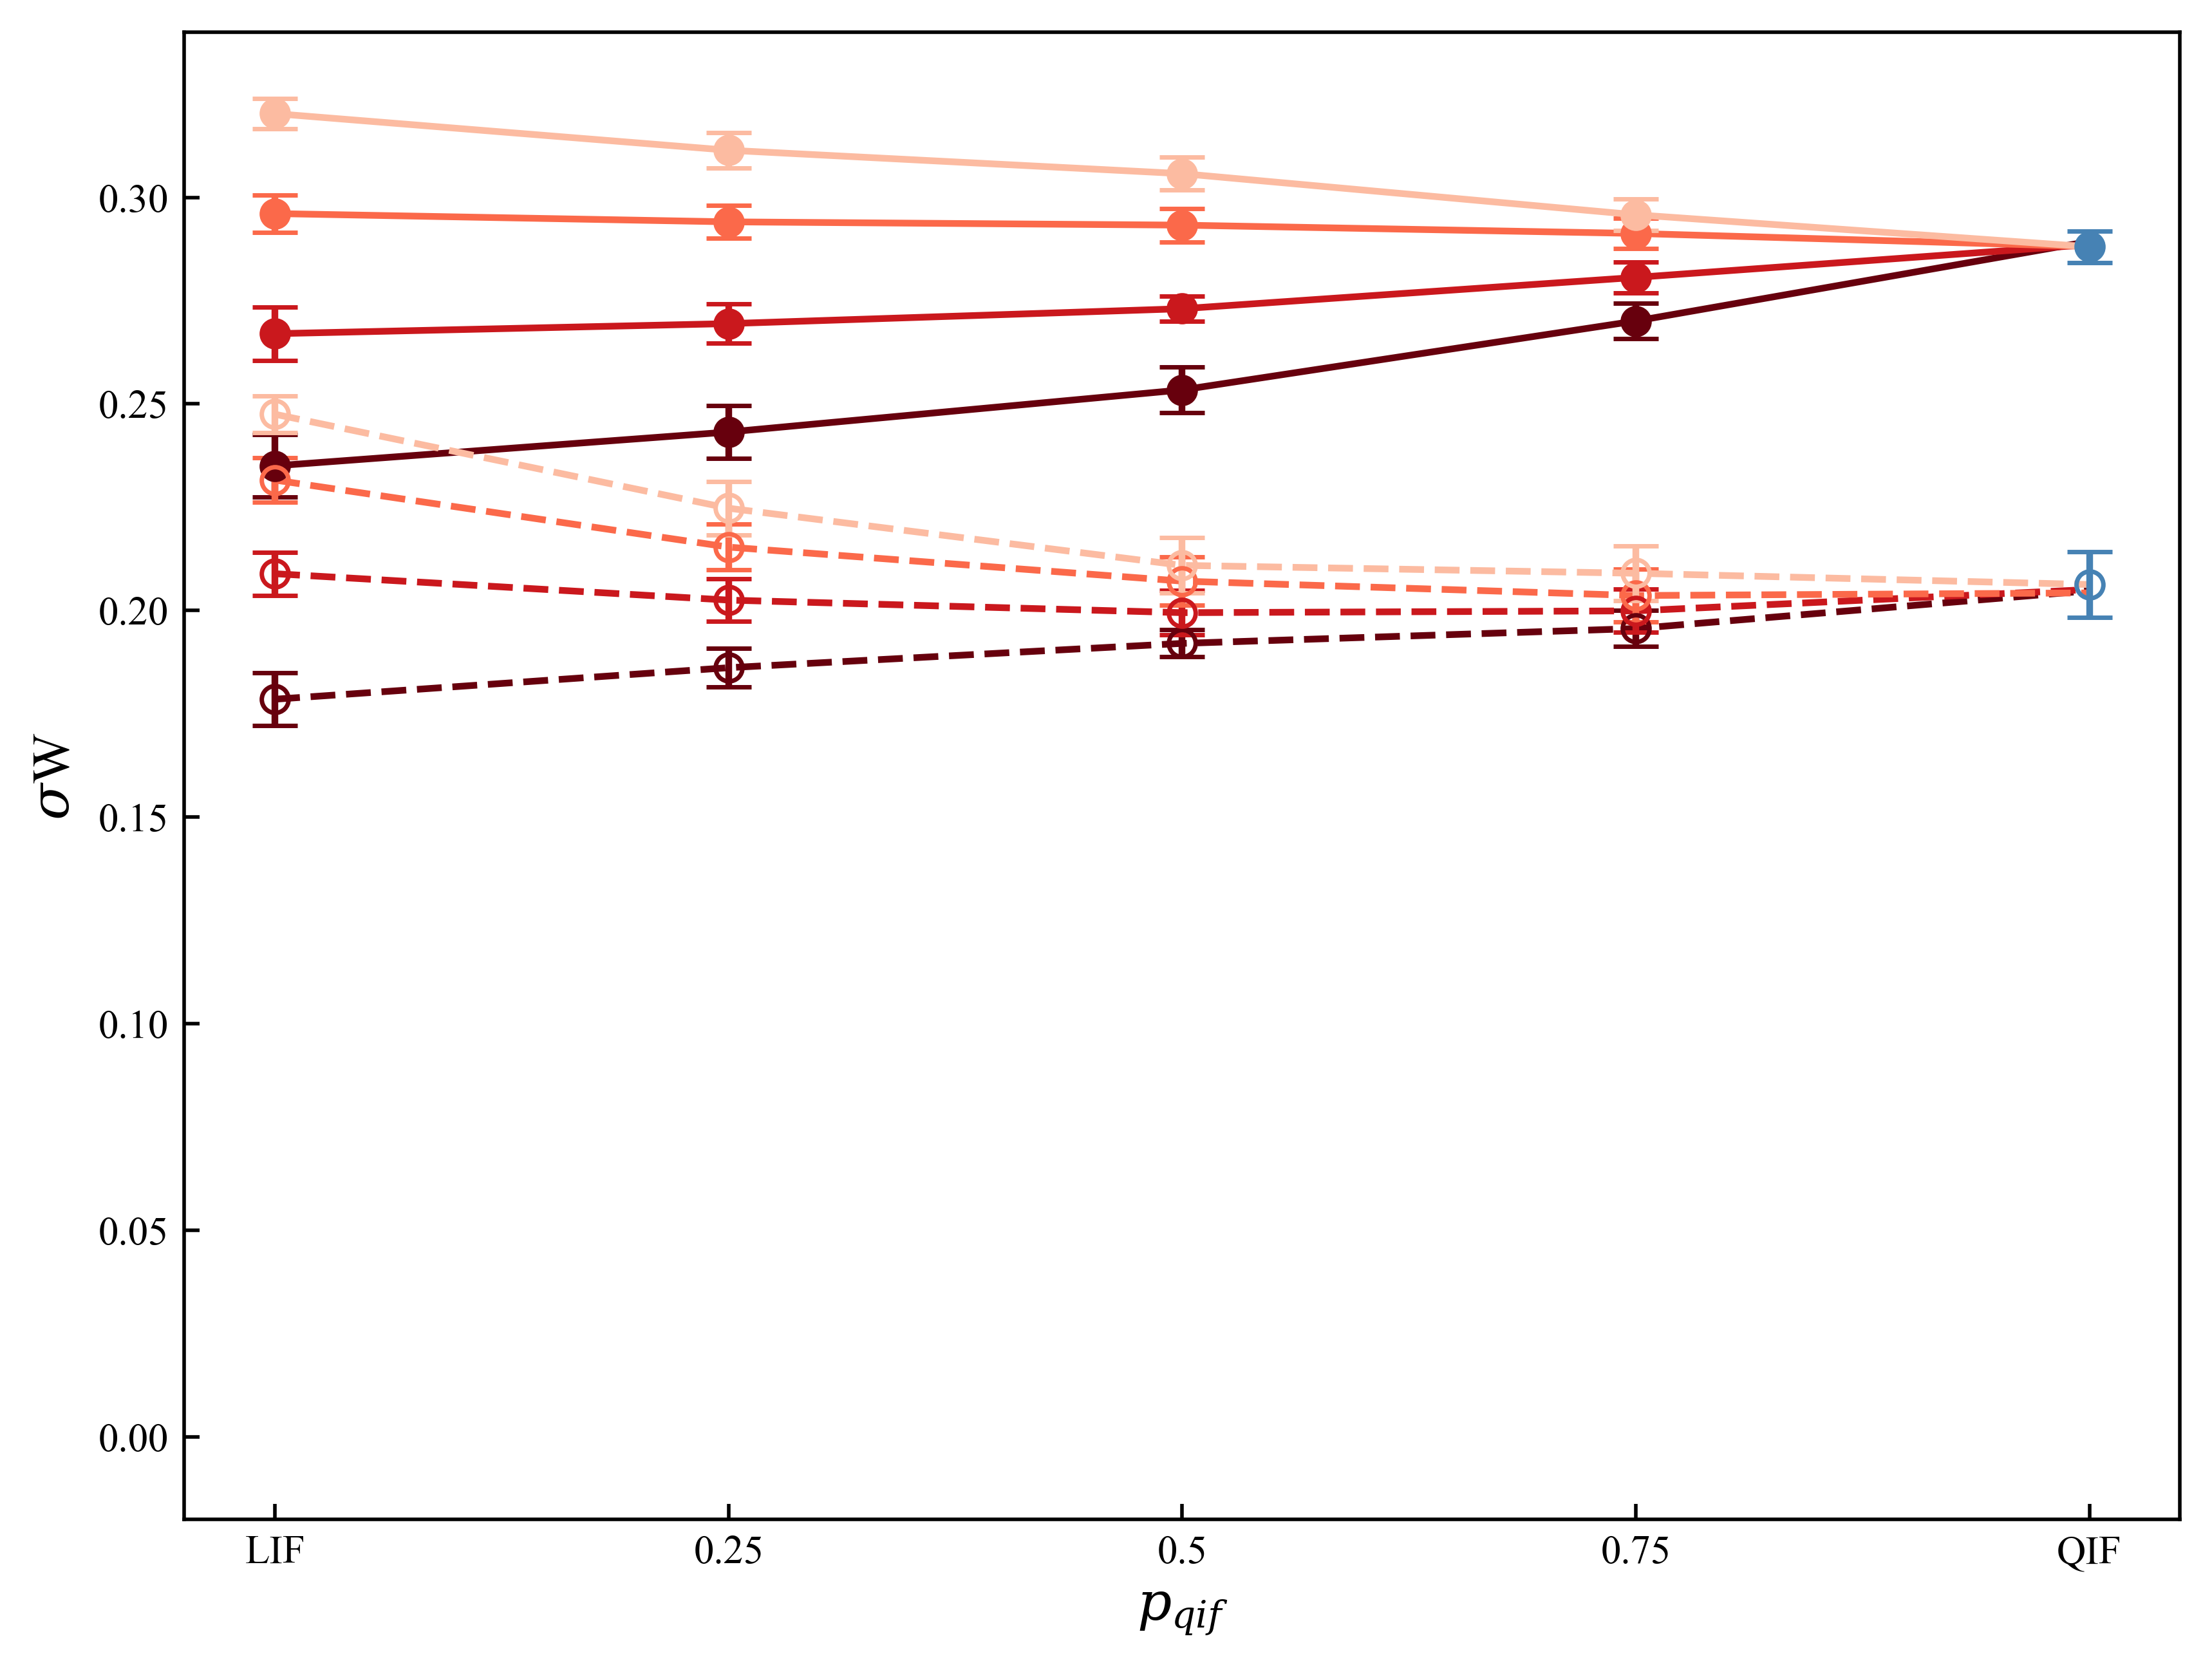

In [22]:
# ========== Mean of weights vs. pqif for heterogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['mean']
columns = ['mean', 'std']

x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

########## Figure loop ##########

#### Plot same figures for both STD and mean
for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    figname = f"both_heterogenous_{c}-vs-pqif.svg"

    for dyn in dynamics:

        #### Correct simulaton numbers from dynamics

        # if dyn == 'oscillations':
        #     simulation_number = [i for i in range(1,5)]
        # elif dyn == 'sequences':
        #     simulation_number = [i for i in range(9, 13)]
        # else:
        #     print('Invalid dynamics')
        #     sys.exit()

        # simulation_number, vrest, slope = ([1], [-8.5], [14.44])  if dyn == 'oscillations' else ([9], [-8.5], [14.44])


        
        # simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]
        # fillstyle = 'full' if dyn == 'oscillations' else 'none'

        simulation_number, fillstyle, linestyle = ([i for i in range(1,5)], 'full', '-') if dyn == 'oscillations' else ([i for i in range(9,13)], 'none', '--')


        for sim, vr, f in zip(simulation_number, vrest, slope):
        

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]

            # if dyn == 'oscillations':
            #     linestyle='-'
            # elif dyn == 'sequences':
            #     linestyle = '--'

            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', fillstyle=fillstyle, capsize=5, color=color_map_vrest[vr], label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########
        if c == 'std':
            title = f"$\sigma$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\sigma$W"

        elif c == "mean":
            title = f"$\mu$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\mu$W"


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None


        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, fillstyle=fillstyle, color='steelblue', label=label)

    # ax.set_title(title)
    ax.set_ylim(-0.02, 0.34) if c == 'std' else ax.set_ylim(-0.002, 0.024)
    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    # ax.axhline(0, color='black')
    # if dyn == 'oscillations':
    #     ax.set_ylim(-0.02, 0.34)
    # else:
    #     ax.set_ylim(-0.002, 0.024)

    ##### LEGEND
    # handles, labels = ax.get_legend_handles_labels()
    markersize=15

    # # Create two proxy artists for filled/unfilled
    # from matplotlib.lines import Line2D

    # # color = color_map_vrest[vr]
    # # color = 'gray'


    # filled = Line2D(
    #     [], [], marker='o', linestyle='None',
    #     markerfacecolor=color, markersize=markersize, markeredgecolor=color,
    #     label='Oscillations'
    # )

    # unfilled = Line2D(
    #     [], [], marker='o', linestyle='None',
    #     markerfacecolor='none', markersize=markersize, markeredgecolor=color,
    #     label='Sequences'
    # )

    # axs[1].legend(
    #     handles=[filled, unfilled] + handles,
    #     labels=[filled.get_label(), unfilled.get_label()] + labels,
    #     # loc="upper left",
    #     markerscale=0.6
    #  )

    from matplotlib.lines import Line2D
    from matplotlib.legend_handler import HandlerTuple

    legend_handles = []
    legend_labels = []

    ### pqif entries: filled + unfilled per color
    pqif_heterogenous = [0.25, 0.5, 0.75]
    slope = slope
    vrest = [-8.5, -12.3, -17, -22]
    # color_vrest = [vr for vr in color_map_vrest[vr]]

    lif_text_only = Line2D(
        [], [],
        linestyle='None',   # no line
        marker=None         # no marker
    )

    lif_label = "LIF"
    legend_handles.insert(0, lif_text_only)
    legend_labels.insert(0, lif_label)

    for vr, f in zip(vrest, slope):

        color = color_map_vrest[vr]

        filled = Line2D(
            [], [], marker='o', linestyle='-',
            color=color,
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=markersize
        )

        unfilled = Line2D(
            [], [], marker='o', linestyle='--',
            color=color,
            markerfacecolor='none',
            markeredgecolor=color,
            markersize=markersize
        )

        legend_handles.append((filled, unfilled))
        legend_labels.append(f"$F'$={f}")


    qif_filled = Line2D(
        [], [],
        marker='o',
        linestyle='-',
        color='steelblue',
        markerfacecolor='steelblue',
        markeredgecolor='steelblue',
        markersize=markersize
    )

    qif_unfilled = Line2D(
        [], [],
        marker='o',
        linestyle='--',
        color='steelblue',
        markerfacecolor='none',
        markeredgecolor='steelblue',
        markersize=markersize
    )

    qif_handle = (qif_filled, qif_unfilled)
    qif_label = "QIF\n$F'=10.74$"

    insert_idx = len(legend_handles) 

    legend_handles.insert(insert_idx, qif_handle)
    legend_labels.insert(insert_idx, qif_label)



    ### Final legend
    # ax.legend(
    #     handles=legend_handles,
    #     labels=legend_labels,
    #     loc="upper right",
    #     bbox_to_anchor=(1, 0.5),
    #     markerscale=0.6,
    #     handler_map={tuple: HandlerTuple(ndivide=None)}
    # )


    # plt.legend()
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()


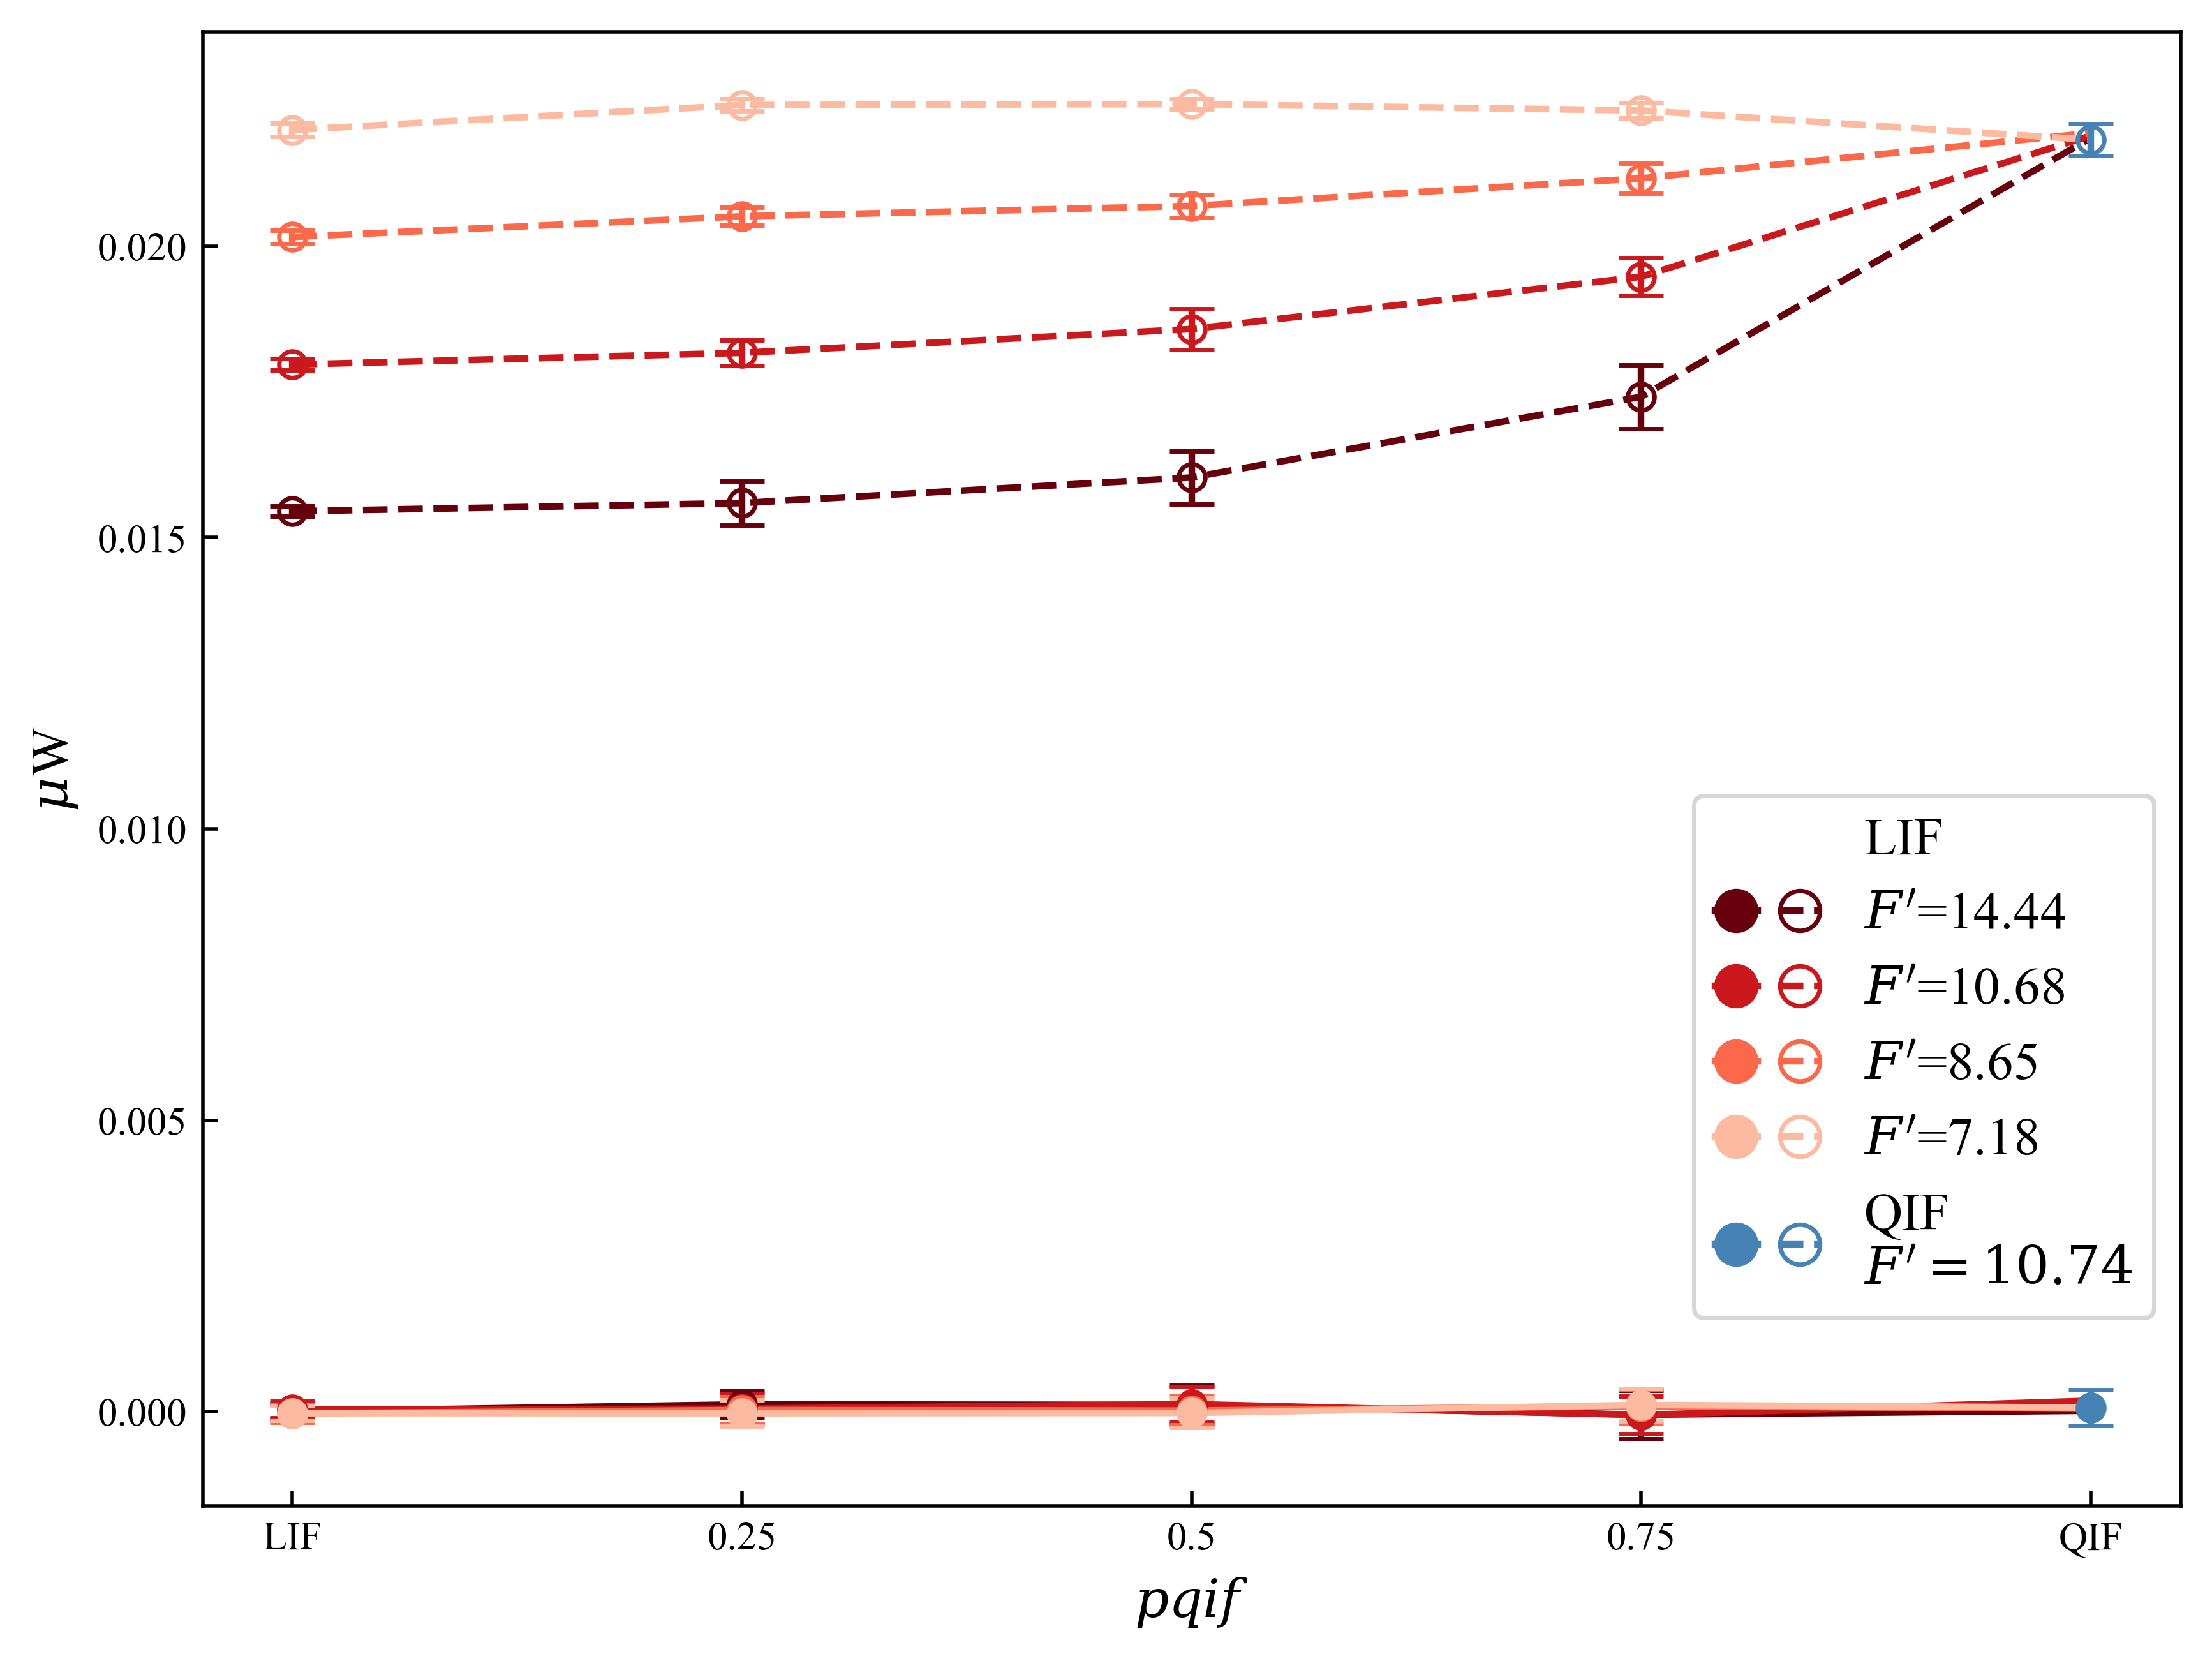

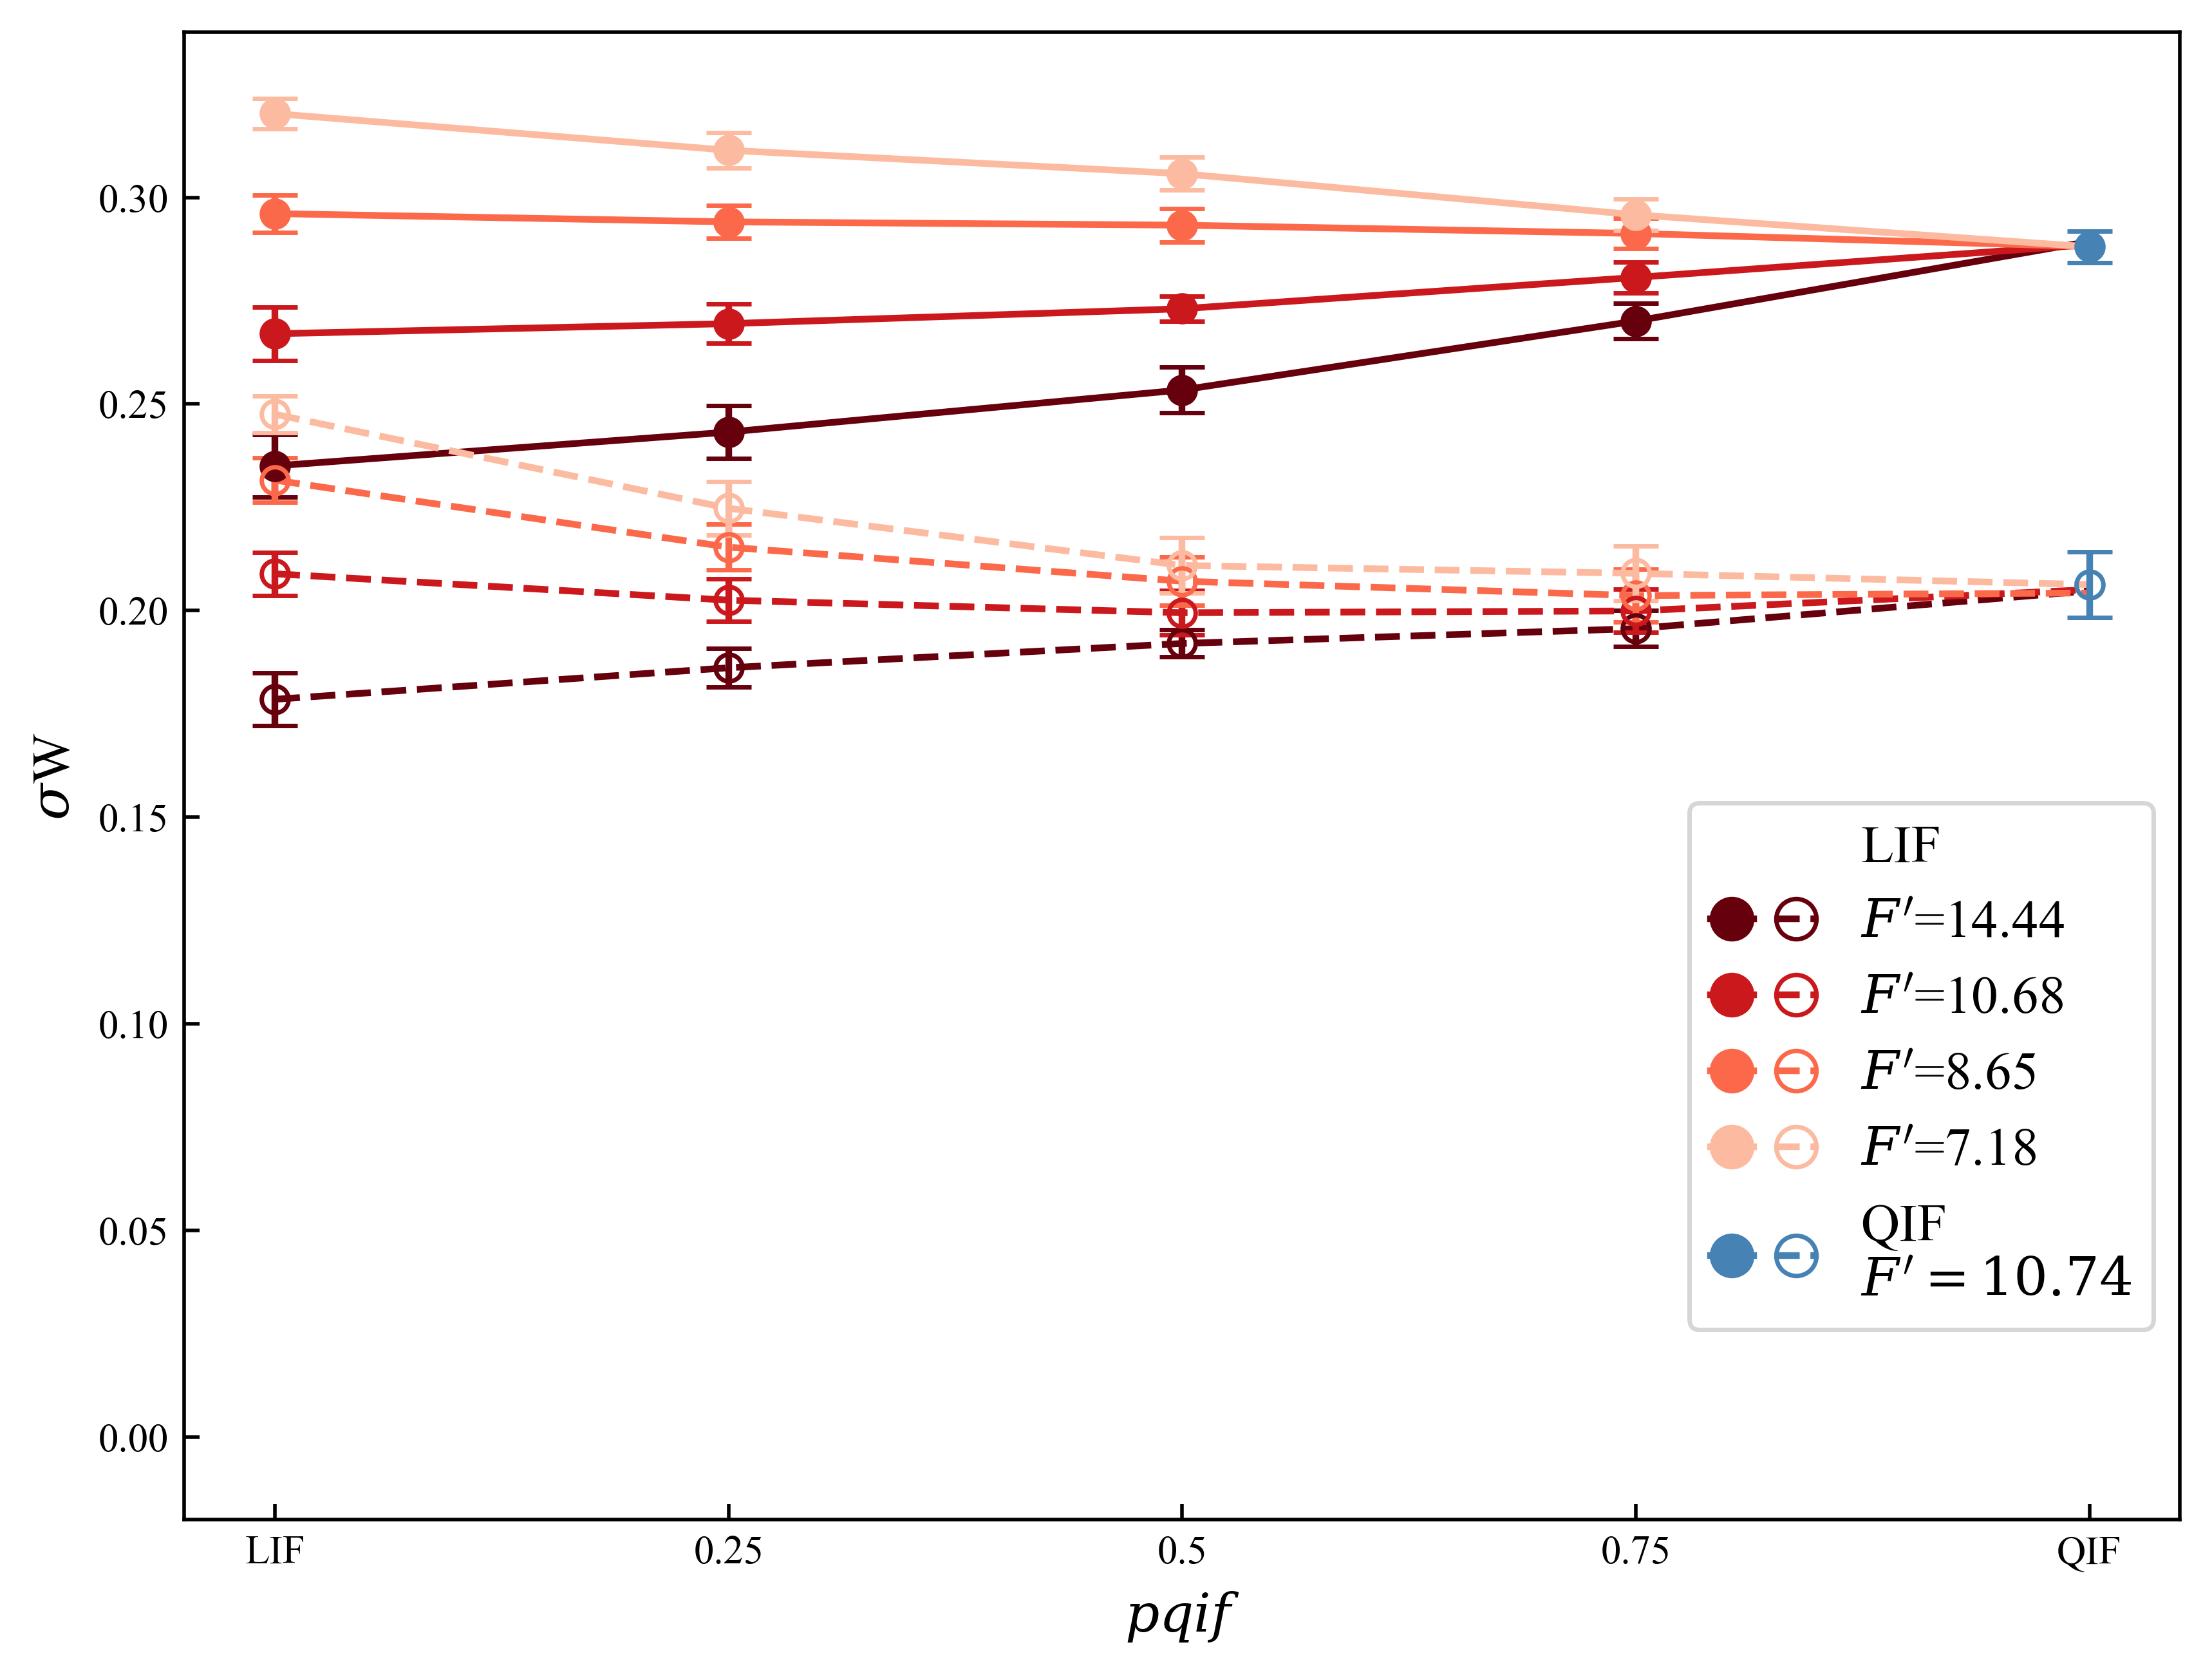

In [37]:
# ========== Mean of weights vs. pqif for heterogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['mean']
columns = ['mean', 'std']

x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

########## Figure loop ##########

#### Plot same figures for both STD and mean
for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    figname = f"both_heterogenous_{c}-vs-pqif.svg"

    for dyn in dynamics:

        #### Correct simulaton numbers from dynamics

        if dyn == 'oscillations':
            simulation_number = [i for i in range(1,5)]
        elif dyn == 'sequences':
            simulation_number = [i for i in range(9, 13)]
        else:
            print('Invalid dynamics')
            sys.exit()

        # simulation_number1 = [simulation_number[1]]
        # vrest1 = [vrest[1]]
        # slope1 = [slope[1]]

        # for sim, vr, f in zip(simulation_number1, vrest1, slope1):
        for sim, vr, f in zip(simulation_number, vrest, slope):

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]

            if dyn == 'oscillations':
                linestyle='-'
                color=color_map_vrest[vr]
                markerfacecolor=color_map_vrest[vr]
                markeredgecolor=color_map_vrest[vr]
            elif dyn == 'sequences':
                linestyle = '--'
                markerfacecolor='None'
                color=color_map_vrest[vr]
                markeredgecolor=color_map_vrest[vr]

            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)


            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', capsize=5, color=color, markerfacecolor=markerfacecolor, markeredgecolor=markeredgecolor, label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)
            # ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            # ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########
        if c == 'std':
            title = f"$\sigma$W vs. $pqif$"
            xlabel = f"$pqif$"
            ylabel = f"$\sigma$W"

        elif c == "mean":
            title = f"$\mu$W vs. $pqif$"
            xlabel = f"$pqif$"
            ylabel = f"$\mu$W"


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None

        if dyn == 'oscillations':
            linestyle='-'
            color='steelblue'
            markerfacecolor='steelblue'
            markeredgecolor='steelblue'
        elif dyn == 'sequences':
            linestyle = '--'
            markerfacecolor='None'
            color='steelblue'
            markeredgecolor='steelblue'

        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, color='steelblue', markerfacecolor=markerfacecolor, markeredgecolor=markeredgecolor, label=label)
        # ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, color='steelblue', label=label)

    if c == 'std':
        ax.set_ylim(-0.02, 0.34)
    # ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    # ax.axhline(0, color='black')

    ##### LEGEND
    # handles, labels = ax.get_legend_handles_labels()
    markersize=15

    # # Create two proxy artists for filled/unfilled
    # from matplotlib.lines import Line2D

    # # color = color_map_vrest[vr]
    # # color = 'gray'


    # filled = Line2D(
    #     [], [], marker='o', linestyle='None',
    #     markerfacecolor=color, markersize=markersize, markeredgecolor=color,
    #     label='Oscillations'
    # )

    # unfilled = Line2D(
    #     [], [], marker='o', linestyle='None',
    #     markerfacecolor='none', markersize=markersize, markeredgecolor=color,
    #     label='Sequences'
    # )

    # axs[1].legend(
    #     handles=[filled, unfilled] + handles,
    #     labels=[filled.get_label(), unfilled.get_label()] + labels,
    #     # loc="upper left",
    #     markerscale=0.6
    #  )

    from matplotlib.lines import Line2D
    from matplotlib.legend_handler import HandlerTuple

    legend_handles = []
    legend_labels = []

    ### pqif entries: filled + unfilled per color
    pqif_heterogenous = [0.25, 0.5, 0.75]
    slope = slope
    vrest = [-8.5, -12.3, -17, -22]
    # color_vrest = [vr for vr in color_map_vrest[vr]]

    text_only = Line2D(
        [], [],
        linestyle='None',   # no line
        marker=None         # no marker
    )

    lif_label = "LIF"
    legend_handles.insert(0, text_only)
    legend_labels.insert(0, lif_label)

    for vr, f in zip(vrest, slope):

        color = color_map_vrest[vr]

        filled = Line2D(
            [], [], marker='o', linestyle='-',
            color=color,
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=markersize
        )

        unfilled = Line2D(
            [], [], marker='o', linestyle='--',
            color=color,
            markerfacecolor='none',
            markeredgecolor=color,
            markersize=markersize
        )

        legend_handles.append((filled, unfilled))
        legend_labels.append(f"$F'$={f}")


    # legend_handles.insert(3, text_only)
    # legend_labels.insert(3, f"\n")

    # legend_handles.insert(6, text_only)
    # legend_labels.insert(6, f"\n")

    qif_filled = Line2D(
        [], [],
        marker='o',
        linestyle='-',
        color='steelblue',
        markerfacecolor='steelblue',
        markeredgecolor='steelblue',
        markersize=markersize
    )

    qif_unfilled = Line2D(
        [], [],
        marker='o',
        linestyle='--',
        color='steelblue',
        markerfacecolor='none',
        markeredgecolor='steelblue',
        markersize=markersize
    )

    qif_handle = (qif_filled, qif_unfilled)
    qif_label = "QIF\n$F'=10.74$"

    insert_idx = len(legend_handles) 

    legend_handles.insert(insert_idx, qif_handle)
    legend_labels.insert(insert_idx, qif_label)



    ### Final legend
    ax.legend(
        ncols=1,
        handles=legend_handles,
        labels=legend_labels,
        loc="upper right",
        bbox_to_anchor=(1, 0.5),
        markerscale=0.6,
        handler_map={tuple: HandlerTuple(ndivide=None)}
    )


    # plt.legend()
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()


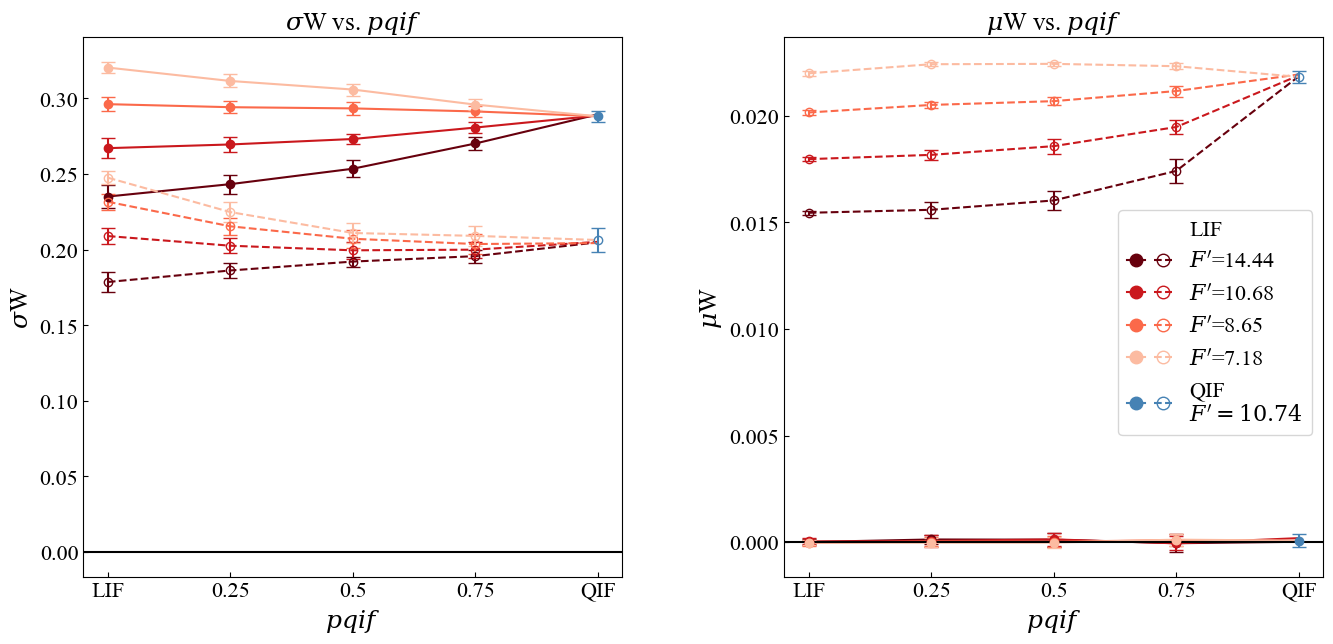

In [101]:
# ========== Mean of weights vs. pqif for heterogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['mean']
# columns = ['mean', 'std']
columns = ['std', 'mean']

x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

########## Figure loop ##########

#### Plot same figures for both STD and mean
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 12),
    sharey=False,
    sharex=False
)  # Both dynamics should be in the same figure for this one
# figname = f"both_mean_vs_pqif.svg"

fig.subplots_adjust(
    wspace=0.3
)
for i, c in enumerate(columns):
    ax = axs[i]

    for dyn in dynamics:

        #### Correct simulaton numbers from dynamics

        if dyn == 'oscillations':
            simulation_number = [i for i in range(1,5)]
        elif dyn == 'sequences':
            simulation_number = [i for i in range(9, 13)]
        else:
            print('Invalid dynamics')
            sys.exit()


        for sim, vr, f in zip(simulation_number, vrest, slope):

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]

            if dyn == 'oscillations':
                linestyle='-'
                color=color_map_vrest[vr]
                markerfacecolor=color_map_vrest[vr]
                markeredgecolor=color_map_vrest[vr]
            elif dyn == 'sequences':
                linestyle = '--'
                markerfacecolor='None'
                color=color_map_vrest[vr]
                markeredgecolor=color_map_vrest[vr]

            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', capsize=5, color=color, markerfacecolor=markerfacecolor, markeredgecolor=markeredgecolor, label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########
        if c == 'std':
            title = f"$\sigma$W vs. $pqif$"
            xlabel = f"$pqif$"
            ylabel = f"$\sigma$W"

        elif c == "mean":
            title = f"$\mu$W vs. $pqif$"
            xlabel = f"$pqif$"
            ylabel = f"$\mu$W"


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        # if dyn == 'oscillations': # first
        #     label = f"QIF\n$F'$={slope_qif}"
        # else:
        #     label = None

        if dyn == 'oscillations':
            linestyle='-'
            color='steelblue'
            markerfacecolor='steelblue'
            markeredgecolor='steelblue'
        elif dyn == 'sequences':
            linestyle = '--'
            markerfacecolor='None'
            color='steelblue'
            markeredgecolor='steelblue'

        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, color='steelblue', markerfacecolor=markerfacecolor, markeredgecolor=markeredgecolor, label=label)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='black')
    ax.set_box_aspect(1)


##### LEGEND
# handles, labels = ax.get_legend_handles_labels()
markersize=15

# # Create two proxy artists for filled/unfilled
# from matplotlib.lines import Line2D

# # color = color_map_vrest[vr]
# # color = 'gray'


# filled = Line2D(
#     [], [], marker='o', linestyle='None',
#     markerfacecolor=color, markersize=markersize, markeredgecolor=color,
#     label='Oscillations'
# )

# unfilled = Line2D(
#     [], [], marker='o', linestyle='None',
#     markerfacecolor='none', markersize=markersize, markeredgecolor=color,
#     label='Sequences'
# )

# axs[1].legend(
#     handles=[filled, unfilled] + handles,
#     labels=[filled.get_label(), unfilled.get_label()] + labels,
#     # loc="upper left",
#     markerscale=0.6
#  )

from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

legend_handles = []
legend_labels = []

### pqif entries: filled + unfilled per color
pqif_heterogenous = [0.25, 0.5, 0.75]
slope = slope
vrest = [-8.5, -12.3, -17, -22]
# color_vrest = [vr for vr in color_map_vrest[vr]]

lif_text_only = Line2D(
    [], [],
    linestyle='None',   # no line
    marker=None         # no marker
)

lif_label = "LIF"
legend_handles.insert(0, lif_text_only)
legend_labels.insert(0, lif_label)

for vr, f in zip(vrest, slope):

    color = color_map_vrest[vr]

    filled = Line2D(
        [], [], marker='o', linestyle='-',
        color=color,
        markerfacecolor=color,
        markeredgecolor=color,
        markersize=markersize
    )

    unfilled = Line2D(
        [], [], marker='o', linestyle='--',
        color=color,
        markerfacecolor='none',
        markeredgecolor=color,
        markersize=markersize
    )

    legend_handles.append((filled, unfilled))
    legend_labels.append(f"$F'$={f}")





### Final control entry

# oscillations_marker = Line2D(
#         [], [], marker='o', linestyle='-',
#         color='black',
#         markerfacecolor='black',
#         markeredgecolor='black',
#         markersize=markersize,
#         alpha=0.3
#     )

# sequence_marker = Line2D(
#         [], [], marker='o', linestyle='--',
#         color='black',
#         markerfacecolor='none',
#         markeredgecolor='black',
#         markersize=markersize,
#         alpha=0.3
#     )


# # full_connectivity = Line2D(
# #     [], [], linestyle='-',
# #     # markerfacecolor='black',
# #     # markeredgecolor='black',
# #     # markersize=markersize,
# #     color='black',
# #     alpha=0.3,
# # )

# # legend_handles.append((control_solid, control_dashed))
# legend_handles.append((oscillations_marker))
# legend_labels.append("Oscillations")
# legend_handles.append((sequence_marker))
# legend_labels.append("Sequences")

########## QIF 


# qif_handle = Line2D(
#     [], [],
#     marker='o',
#     linestyle='-',
#     color='steelblue',
#     markerfacecolor='steelblue',
#     markeredgecolor='steelblue',
#     markersize=markersize
# )

# qif_label = "QIF\n$F'=10.74$"

# insert_idx = len(legend_handles) - 2

# legend_handles.insert(insert_idx, qif_handle)
# legend_labels.insert(insert_idx, qif_label)

qif_filled = Line2D(
    [], [],
    marker='o',
    linestyle='-',
    color='steelblue',
    markerfacecolor='steelblue',
    markeredgecolor='steelblue',
    markersize=markersize
)

qif_unfilled = Line2D(
    [], [],
    marker='o',
    linestyle='--',
    color='steelblue',
    markerfacecolor='none',
    markeredgecolor='steelblue',
    markersize=markersize
)

qif_handle = (qif_filled, qif_unfilled)
qif_label = "QIF\n$F'=10.74$"

insert_idx = len(legend_handles) 

legend_handles.insert(insert_idx, qif_handle)
legend_labels.insert(insert_idx, qif_label)



### Final legend
axs[1].legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="upper right",
    bbox_to_anchor=(1, 0.7),
    markerscale=0.6,
    handler_map={tuple: HandlerTuple(ndivide=None)}
)



# plt.legend()
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()
